# Laboratorio 4. Parte 2 — Análisis de modelos usando datos geoespaciales
### CC3084 — Data Science | UVG | Semestre II - 2026
**Integrantes:** Jose Ordoñez - 231329, Adrián González - 23152, José Antón - 221041

Link de GitHub: https://github.com/Ikeel04/Labs-DS.git


## Ejercicio 1. Preparación de los datos para Machine Learning

Partimos de los raster descargados en la Parte I (`data/raster/<lago>/<lago>_<fecha>.tif`
con bandas `B03`, `B04`, `B08`, y `data/raster/<lago>/<lago>_<fecha>_B05.tif`), usando
las mismas 11 fechas por lago. Este notebook asume que la Parte I ya se ejecutó y que
esos archivos existen en disco.

Cada fila del dataset de Machine Learning representará **un píxel de agua válido** de
una imagen (lago, fecha), con sus coordenadas, bandas espectrales, índices (NDVI, NDWI)
y el índice de cianobacteria (Chl-a) asociado.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import transform as warp_transform
import matplotlib.pyplot as plt
import seaborn as sns

RASTER_DIR = Path("data/raster")
OUT_DIR = Path("data")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# --- Mismas fechas y lagos utilizados en la Parte I ---
fechas_atitlan = [
    "2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21",
    "2025-12-29", "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28",
    "2026-07-22",
]

fechas_amatitlan = [
    "2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08",
    "2026-02-02", "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28",
    "2026-06-19",
]

fechas_por_lago = {
    "atitlan": fechas_atitlan,
    "amatitlan": fechas_amatitlan,
}

for lago, fechas in fechas_por_lago.items():
    print(f"{lago}: {len(fechas)} fechas oficiales")

atitlan: 11 fechas oficiales
amatitlan: 11 fechas oficiales


### 1.1–1.2 Construcción del dataset a nivel de píxel

Para cada imagen (lago, fecha) leemos las bandas `B03`, `B04`, `B08` (raster principal)
y `B05` (raster adicional, usado en la Parte I para el índice de cianobacteria/NDCI),
calculamos NDVI, NDWI y el índice de cianobacteria (Chl-a), y generamos las coordenadas
(longitud/latitud) de cada píxel.

Debido a la resolución de 10 m, una imagen completa tiene del orden de millones de
píxeles; para evitar un dataset excesivamente grande y con fuerte redundancia espacial
entre píxeles vecinos, submuestreamos con un `PIXEL_STRIDE` (tomamos 1 de cada N píxeles
en filas y columnas). Esto se documenta y se puede ajustar en la sección 1.6.

In [3]:
# Funciones de lectura e índices

def leer_bandas(ruta_principal, ruta_b05):
    with rasterio.open(ruta_principal) as src:
        b03 = src.read(1).astype("float32")
        b04 = src.read(2).astype("float32")
        b08 = src.read(3).astype("float32")
        crs = src.crs
        transform = src.transform
    with rasterio.open(ruta_b05) as src2:
        b05 = src2.read(1).astype("float32")
    return b03, b04, b08, b05, crs, transform


def calcular_indices(b03, b04, b08, b05):
    NODATA = -1000
    for b in (b03, b04, b08, b05):
        b[:] = np.where(b <= NODATA, np.nan, b) / 10000.0
    b03, b04, b08, b05 = (np.clip(b, 0.0, 1.0) for b in (b03, b04, b08, b05))

    eps = 1e-6
    ndvi = (b08 - b04) / (b08 + b04 + eps)
    ndwi = (b03 - b08) / (b03 + b08 + eps)
    ndci = (b05 - b04) / (b05 + b04 + eps)

    ndci = np.clip(ndci, -1.0, 1.0)
    with np.errstate(over="ignore"):
        chl_a = 17.441 * np.exp(4.7038 * ndci)
    return b03, b04, b08, b05, ndvi, ndwi, chl_a


def mascara_agua(ndwi, umbral=0.0):
    return ndwi > umbral

In [4]:
PIXEL_STRIDE = 5  # 1 de cada 5 píxeles en filas y columnas (ver 1.6)


def construir_observaciones(lago, fecha, ruta_principal, ruta_b05, stride=PIXEL_STRIDE):
    """Devuelve un DataFrame con una fila por píxel de agua válido, con sus
    coordenadas, bandas espectrales, NDVI, NDWI e índice de cianobacteria."""
    b03, b04, b08, b05, crs, transform = leer_bandas(ruta_principal, ruta_b05)
    b03, b04, b08, b05, ndvi, ndwi, chl_a = calcular_indices(b03, b04, b08, b05)
    agua = mascara_agua(ndwi)

    # Submuestreo por stride (antes de aplicar la máscara, para mantener el
    # patrón de rejilla regular en filas/columnas)
    H, W = ndwi.shape
    filas = np.arange(0, H, stride)
    cols = np.arange(0, W, stride)
    rr, cc = np.meshgrid(filas, cols, indexing="ij")

    m = agua[rr, cc]
    # También descartamos cualquier NaN remanente (nodata / bordes) en
    # cualquiera de las bandas o índices
    validos = (
        m
        & ~np.isnan(b03[rr, cc]) & ~np.isnan(b04[rr, cc])
        & ~np.isnan(b08[rr, cc]) & ~np.isnan(b05[rr, cc])
        & ~np.isnan(ndvi[rr, cc]) & ~np.isnan(ndwi[rr, cc])
        & ~np.isnan(chl_a[rr, cc]) & np.isfinite(chl_a[rr, cc])
    )

    rr_v, cc_v = rr[validos], cc[validos]
    if rr_v.size == 0:
        return pd.DataFrame()

    # Coordenadas de cada píxel (centro), transformadas de la proyección
    # nativa del raster a lon/lat (EPSG:4326)
    xs, ys = rasterio.transform.xy(transform, rr_v, cc_v, offset="center")
    lons, lats = warp_transform(crs, "EPSG:4326", xs, ys)

    df = pd.DataFrame({
        "lago": lago,
        "fecha": fecha,
        "lon": lons,
        "lat": lats,
        "b03": b03[rr_v, cc_v],
        "b04": b04[rr_v, cc_v],
        "b08": b08[rr_v, cc_v],
        "b05": b05[rr_v, cc_v],
        "ndvi": ndvi[rr_v, cc_v],
        "ndwi": ndwi[rr_v, cc_v],
        "cianobacteria_indice": chl_a[rr_v, cc_v],
    })
    return df

In [5]:
# --- Construcción del dataset completo (todas las fechas, ambos lagos) ---
partes = []
for lago, fechas in fechas_por_lago.items():
    for fecha in fechas:
        ruta_principal = RASTER_DIR / lago / f"{lago}_{fecha}.tif"
        ruta_b05 = RASTER_DIR / lago / f"{lago}_{fecha}_B05.tif"
        if not ruta_principal.exists() or not ruta_b05.exists():
            print(f"[omitido] Faltan archivos para {lago} - {fecha}")
            continue
        df_obs = construir_observaciones(lago, fecha, ruta_principal, ruta_b05)
        print(f"{lago} - {fecha}: {len(df_obs)} observaciones válidas")
        partes.append(df_obs)

df_ml = pd.concat(partes, ignore_index=True)
df_ml["fecha"] = pd.to_datetime(df_ml["fecha"])
df_ml.to_csv(OUT_DIR / "dataset_ml_pixeles.csv", index=False)
print("\nTotal de observaciones en el dataset:", len(df_ml))
df_ml.head()

atitlan - 2025-01-18: 49085 observaciones válidas
atitlan - 2025-04-13: 49108 observaciones válidas
atitlan - 2025-05-13: 55473 observaciones válidas
atitlan - 2025-07-17: 49021 observaciones válidas
atitlan - 2025-11-21: 50461 observaciones válidas
atitlan - 2025-12-29: 54137 observaciones válidas
atitlan - 2026-02-12: 48999 observaciones válidas
atitlan - 2026-03-24: 50188 observaciones válidas
atitlan - 2026-04-13: 48974 observaciones válidas
atitlan - 2026-04-28: 52370 observaciones válidas
atitlan - 2026-07-22: 48938 observaciones válidas
amatitlan - 2025-01-28: 6323 observaciones válidas
amatitlan - 2025-04-15: 6107 observaciones válidas
amatitlan - 2025-04-28: 5934 observaciones válidas
amatitlan - 2025-11-24: 6156 observaciones válidas
amatitlan - 2026-01-08: 5720 observaciones válidas
amatitlan - 2026-02-02: 5604 observaciones válidas
amatitlan - 2026-02-07: 3148 observaciones válidas
amatitlan - 2026-03-29: 6249 observaciones válidas
amatitlan - 2026-04-13: 6308 observaciones

,lago,fecha,lon,lat,b03,b04,b08,b05,ndvi,ndwi,cianobacteria_indice
0,atitlan,2025-01-18,-91.147514,14.751164,0.3090,0.2976,0.2946,0.1593,-0.005066,0.023857,4.199745
1,atitlan,2025-01-18,-91.147061,14.749805,0.3420,0.4072,0.3216,0.2189,-0.117453,0.030741,4.238268
2,atitlan,2025-01-18,-91.169831,14.747727,0.0129,0.0032,0.0066,0.0312,0.346903,0.323060,802.223633
3,atitlan,2025-01-18,-91.169366,14.747723,0.0085,0.0023,0.0020,0.0000,-0.069751,0.618989,0.158352
4,atitlan,2025-01-18,-91.168902,14.747720,0.0096,0.0012,0.0005,0.0013,-0.411523,0.900901,21.049997


### 1.3 Observaciones eliminadas

Durante la construcción del dataset se descartaron:

- **Píxeles fuera del agua**: se usa la máscara `NDWI > 0` (misma máscara de la Parte I)
  como proxy del límite del lago, ya que no se cuenta con un polígono oficial de cada
  lago, solo el bounding box del enunciado.
- **Píxeles con NoData**: reflectancias iguales o menores al valor centinela `-1000`
  (o `NaN` tras la conversión), típicos de bordes de escena o zonas sin cobertura.
- **Píxeles con algún índice indefinido**: NDVI, NDWI o el índice de cianobacteria
  con `NaN` o valores no finitos (por ejemplo, divisiones degeneradas ya cubiertas con
  el término `eps`, pero se valida de todas formas).
- **Nubes**: no se descargó la banda de clasificación de escena (`SCL`), así que no hay
  un filtrado de nubes píxel por píxel en este dataset. La exposición a nubes ya se
  redujo en la Parte I al descargar solo imágenes con `max_cloud_cover <= 20%` y usar
  el reductor de mediana temporal por día; se documenta como limitación y se retoma en
  la sección 1.6.

### 1.4 Resumen del dataset

In [6]:
print("Total de observaciones:", len(df_ml))
print()
print("Observaciones por lago:")
display(df_ml.groupby("lago").size().rename("n_observaciones"))
print()
print("Observaciones por lago y fecha:")
display(df_ml.groupby(["lago", "fecha"]).size().rename("n_observaciones"))

Total de observaciones: 620063

Observaciones por lago:


lago
amatitlan     63309
atitlan      556754
Name: n_observaciones, dtype: int64


Observaciones por lago y fecha:


lago       fecha     
amatitlan  2025-01-28     6323
           2025-04-15     6107
           2025-04-28     5934
           2025-11-24     6156
           2026-01-08     5720
           2026-02-02     5604
           2026-02-07     3148
           2026-03-29     6249
           2026-04-13     6308
           2026-04-28     5272
           2026-06-19     6488
atitlan    2025-01-18    49085
           2025-04-13    49108
           2025-05-13    55473
           2025-07-17    49021
           2025-11-21    50461
           2025-12-29    54137
           2026-02-12    48999
           2026-03-24    50188
           2026-04-13    48974
           2026-04-28    52370
           2026-07-22    48938
Name: n_observaciones, dtype: int64

In [7]:
print("Variables disponibles y tipo de dato:")
tipos = df_ml.dtypes.rename("tipo").to_frame()
tipos["% valores faltantes"] = (df_ml.isna().mean() * 100).round(2)
display(tipos)

Variables disponibles y tipo de dato:


,tipo,% valores faltantes
lago,object,0.0
fecha,datetime64[ns],0.0
lon,float64,0.0
lat,float64,0.0
b03,float32,0.0
b04,float32,0.0
b08,float32,0.0
b05,float32,0.0
ndvi,float32,0.0
ndwi,float32,0.0


En total quedaron 620,063 puntos de agua analizados. De esos, el 556,754 son de Atitlán y solo 63,309 de Amatitlán. Atitlán al ser un lago mucho más grande en superficie, tiene sentido que al recorrer su espejo de agua salen muchos más puntos que en Amatitlán, que es bastante más pequeño. Dentro de cada lago, la cantidad de puntos por fecha es bastante pareja, con una excepción clara: la fecha 2026-02-07 de Amatitlán tiene casi la mitad de puntos que las demás fechas de ese lago.

Ninguna de las columnas del dataset tiene datos faltantes. Ya se habían descartado antes todos los píxeles con datos inválidos (nubes, bordes, valores sin sentido), así que lo que llegó a esta tabla ya viene "limpio".

### 1.5 Análisis exploratorio de las variables

In [8]:
variables_numericas = ["b03", "b04", "b08", "b05", "ndvi", "ndwi", "cianobacteria_indice"]
print("Estadísticas descriptivas:")
display(df_ml[variables_numericas].describe())

print()
print("Estadísticas por lago:")
display(df_ml.groupby("lago")[variables_numericas].describe().T)

Estadísticas descriptivas:


,b03,b04,b08,b05,ndvi,ndwi,cianobacteria_indice
count,620063.000000,620063.000000,620063.000000,620063.000000,620063.000000,620063.000000,620063.000000
mean,0.046776,0.035770,0.034205,0.038203,-0.062819,0.474679,37.487545
std,0.136445,0.135654,0.132769,0.139925,0.306254,0.247488,164.438843
min,0.000100,0.000000,0.000000,0.000000,-0.999965,0.000091,0.158075
25%,0.011800,0.003100,0.002900,0.002800,-0.113630,0.296391,13.651469
50%,0.019600,0.009000,0.007500,0.008900,-0.036231,0.442013,17.441000
75%,0.026400,0.015600,0.014500,0.016700,0.012285,0.621329,21.174229
max,1.000000,1.000000,0.999500,1.000000,0.999867,0.999983,1924.392334



Estadísticas por lago:


lago                           amatitlan        atitlan
b03                  count  63309.000000  556754.000000
                     mean       0.071945       0.043914
                     std        0.107396       0.139077
                     min        0.002200       0.000100
                     25%        0.021900       0.011400
                     50%        0.054800       0.018900
                     75%        0.072900       0.024600
                     max        1.000000       1.000000
b04                  count  63309.000000  556754.000000
                     mean       0.052345       0.033886
                     std        0.106992       0.138413
                     min        0.000900       0.000000
                     25%        0.013400       0.002700
                     50%        0.027500       0.008400
                     75%        0.045100       0.013600
                     max        1.000000       1.000000
b08                  count  63309.000000  556754.000000
                     mean       0.047671       0.032674
                     std        0.102309       0.135716
                     min        0.000000       0.000000
                     25%        0.008300       0.002700
                     50%        0.024700       0.007000
                     75%        0.040300       0.012900
                     max        0.999400       0.999500
b05                  count  63309.000000  556754.000000
                     mean       0.069435       0.034651
                     std        0.104104       0.143001
                     min        0.000000       0.000000
                     25%        0.020700       0.002500
                     50%        0.047600       0.008200
                     75%        0.075200       0.013700
                     max        1.000000       1.000000
ndvi                 count  63309.000000  556754.000000
                     mean      -0.158541      -0.051935
                     std        0.250323       0.310114
                     min       -0.999965      -0.999944
                     25%       -0.242196      -0.101790
                     50%       -0.098168      -0.032256
                     75%       -0.011236       0.014491
                     max        0.564419       0.999867
ndwi                 count  63309.000000  556754.000000
                     mean       0.372451       0.486303
                     std        0.230869       0.246639
                     min        0.000091       0.000208
                     25%        0.210454       0.310506
                     50%        0.337849       0.451720
                     75%        0.510773       0.634585
                     max        0.999983       0.999980
cianobacteria_indice count  63309.000000  556754.000000
                     mean      62.673870      34.623585
                     std       48.537731     172.530212
                     min        0.158277       0.158075
                     25%       29.413521      13.115414
                     50%       50.305302      16.829662
                     75%       75.783218      19.561171
                     max      862.105530    1924.392334

Lo primero que salta es que casi todos los valores de reflectancia (b03, b04, b08, b05 — básicamente qué tanta luz refleja el agua en distintos colores) están muy cerca de cero, tanto en promedio como en la mediana. Esto es normal en agua: el agua absorbe mucha luz y refleja poca, así que la mayoría de los píxeles de agua deberían verse "oscuros" en estos números. Pero el máximo llega hasta 1.0 en varias bandas, lo que indica que hay algunos píxeles atípicos muy brillantes — probablemente reflejos del sol sobre el agua o algún resto de nube que no se filtró del todo.

El NDVI (que normalmente se usa para detectar vegetación) da en promedio un valor negativo, lo cual es justamente lo esperado sobre agua, ya que el agua no tiene vegetación. El NDWI (que marca presencia de agua) da en promedio positivo, como debe ser, confirmando que la máscara de agua está funcionando bien.

Lo más interesante es el índice de cianobacteria: el promedio (37.5) es bastante más alto que la mediana (17.4). Eso quiere decir que la mayoría de los puntos tienen valores bajos, pero hay un grupo pequeño de puntos con valores extremadamente altos (hasta casi 1,924) que jalan el promedio hacia arriba. Comparando lagos: Amatitlán tiene, en promedio, valores de cianobacteria más altos y más parejos (mediana 50.3), mientras que Atitlán tiene un promedio más bajo pero con picos mucho más extremos (máximo 1,924 contra 862 de Amatitlán). Esto encaja exactamente con lo que ya habían visto en la Parte I: Amatitlán tiene un problema más constante y de fondo, mientras que Atitlán tiene episodios puntuales pero muy intensos.

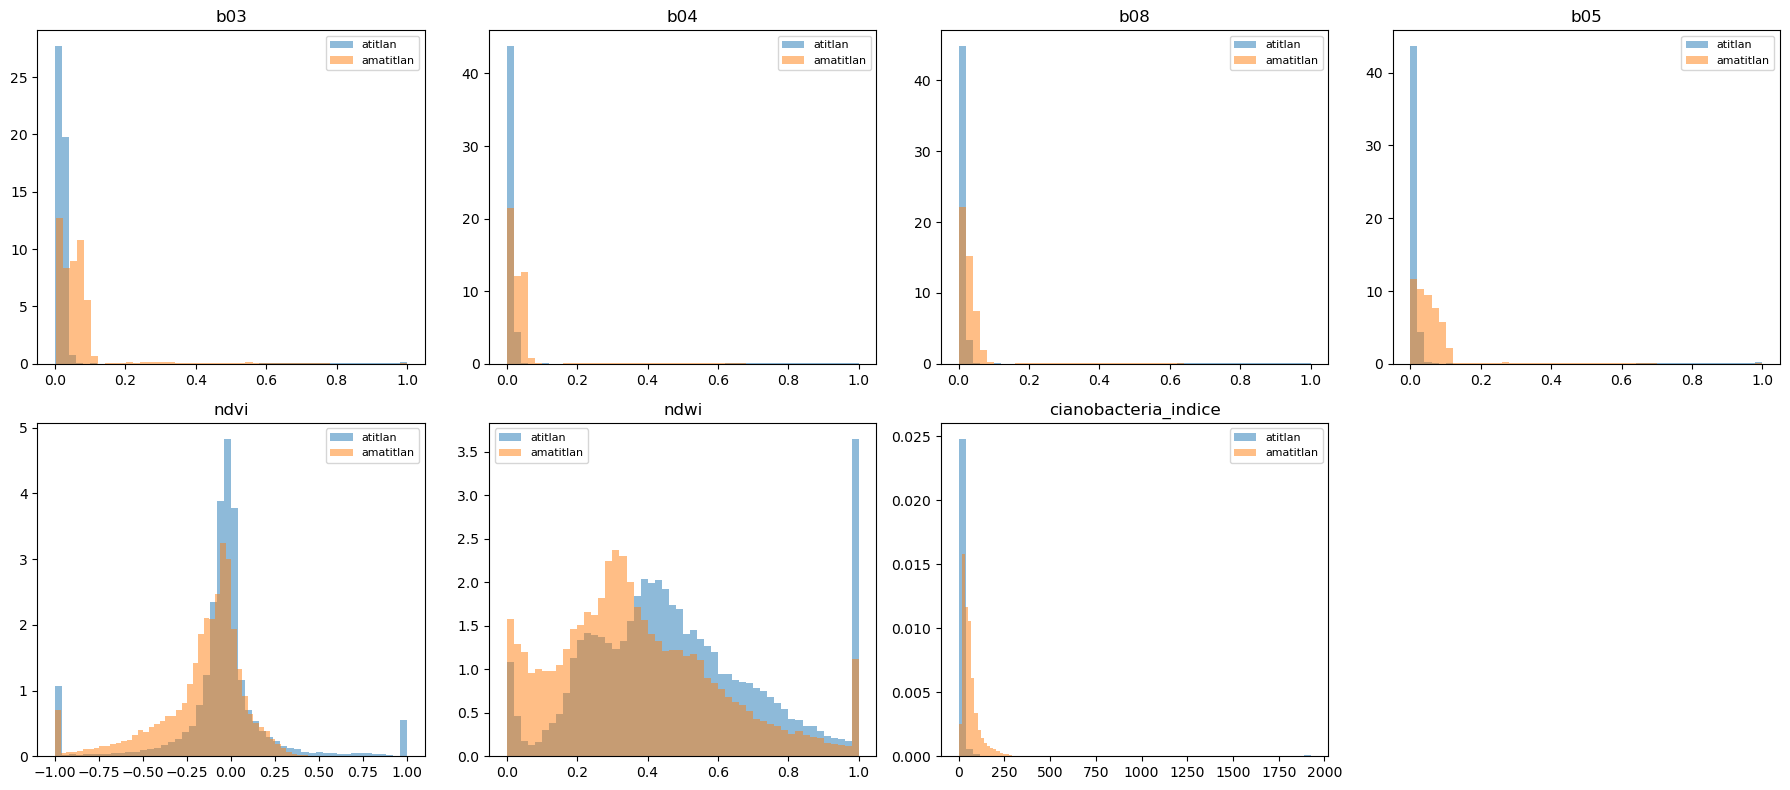

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, var in zip(axes, variables_numericas):
    for lago in df_ml["lago"].unique():
        sub = df_ml[df_ml["lago"] == lago][var]
        ax.hist(sub, bins=50, alpha=0.5, label=lago, density=True)
    ax.set_title(var)
    ax.legend(fontsize=8)
axes[-1].axis("off")
plt.tight_layout()
plt.savefig("data/eda_histogramas_variables.png")
plt.show()

Confirman visualmente lo anterior: las cuatro bandas de reflectancia están casi todas amontonadas cerca de cero para ambos lagos, con muy pocos píxeles hacia valores altos, coherente con agua oscura en su mayoría. El NDVI se ve centrado cerca de cero con una ligera inclinación hacia negativos, más ese pequeño pico aislado en +1.0. El NDWI muestra dos "montañas": una hacia valores bajos-medios y otra grande cerca de 1.0, esa segunda agrupación cerca de 1.0 vale la pena revisarla, podría tratarse de zonas de agua muy profunda o muy calmada donde el índice se satura, y sería bueno confirmarlo antes de usarlo como variable en el modelo.

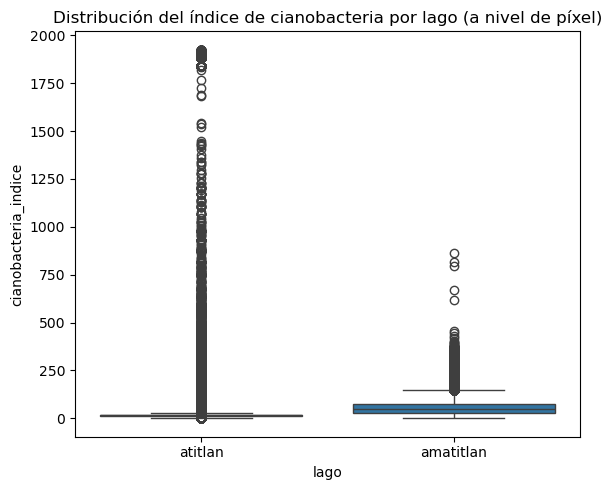

In [10]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df_ml, x="lago", y="cianobacteria_indice", ax=ax)
ax.set_title("Distribución del índice de cianobacteria por lago (a nivel de píxel)")
plt.tight_layout()
plt.savefig("data/eda_boxplot_cianobacteria.png")
plt.show()

Aquí se ve muy claro el contraste entre lagos, Atitlán tiene una caja (donde vive la mayoría de los datos) muy pegada al piso, pero una nube enorme de puntos atípicos que sube hasta casi 2,000, es decir, la gran mayoría del lago tiene niveles bajos, pero hay zonas puntuales con floraciones muy intensas. Amatitlán, en cambio, tiene una caja más alta y más ancha (su "normalidad" ya es más alta) pero con muchos menos extremos hacia arriba. Visualmente resume lo mismo que las estadísticas: Amatitlán como problema crónico y disperso, Atitlán como problema raro pero severo.

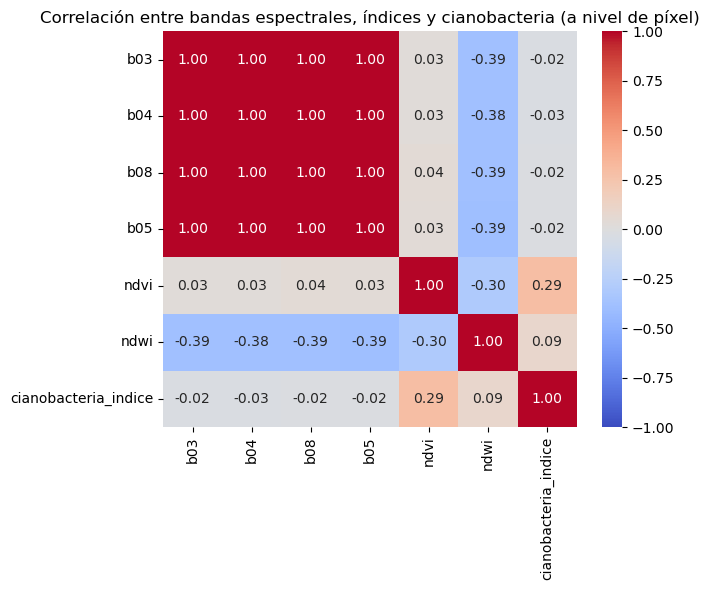

In [11]:
corr = df_ml[variables_numericas].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlación entre bandas espectrales, índices y cianobacteria (a nivel de píxel)")
plt.tight_layout()
plt.savefig("data/eda_correlacion_variables.png")
plt.show()

Las cuatro bandas espectrales (b03, b04, b08, b05) están casi perfectamente correlacionadas entre sí (cercano a 1.00). Esto tiene sentido porque, a nivel de un solo píxel, todas responden más o menos al mismo factor: qué tan clara u oscura/turbia está el agua ahí, si sube una, suben casi todas juntas. Eso también nos dice que estas cuatro bandas, por sí solas, aportan información bastante repetida entre ellas.

En cuanto a la relación con la cianobacteria: el NDVI tiene una correlación positiva moderada (0.29), algo más útil que las bandas crudas. El NDWI, en cambio, tiene una correlación bastante débil con la cianobacteria a este nivel de píxel (0.09), mucho más débil que la relación que habían encontrado en la Parte I. Esto no es contradictorio, en la Parte I se correlacionaban promedios por fecha (11 puntos por lago, ya suavizados), mientras que aquí se está comparando píxel por píxel en las 620 mil observaciones, con mucho más ruido espacial de por medio. Las bandas crudas, por su parte, casi no muestran relación directa con la cianobacteria (cerca de 0), lo que sugiere que los índices derivados (sobre todo el NDVI) van a ser predictores más útiles que las bandas sin procesar.

### 1.6 Decisiones tomadas durante la preparación y limpieza de los datos

**Unidad de observación**: se trabajó a **nivel de píxel** (no de imagen completa),
  siguiendo lo pedido en el enunciado ("cada fila deberá representar una observación
  geográfica válida"). Esto da un dataset con variabilidad espacial explícita, útil
  para los modelos de clasificación de las siguientes secciones.

**Submuestreo espacial (`PIXEL_STRIDE = 5`)**: a resolución nativa de 10 m, cada
  imagen completa tiene del orden de millones de píxeles dentro del bounding box, y los
  píxeles vecinos están muy correlacionados espacialmente (casi no aportan información
  nueva). Por eso se toma 1 de cada 5 píxeles en filas y columnas (equivalente a una
  resolución efectiva de 50 m), lo que reduce el tamaño del dataset manteniendo
  cobertura espacial completa de ambos lagos y las 11 fechas. Este valor es ajustable.

**Límite del lago aproximado por NDWI**: al no contar con un polígono oficial de cada
  lago, se usó la máscara de agua (`NDWI > 0`) ya utilizada en la Parte I como proxy del
  límite físico del lago, y se aplicó de forma consistente en las 22 imágenes.

**Coordenadas en lon/lat (EPSG:4326)**: se guardaron en el sistema geográfico estándar
  para facilitar la inspección y el mapeo; la reproyección a un sistema métrico
  (EPSG:32615, UTM 15N) se hará en el ejercicio de validación espacial más adelante,
  como pide el enunciado.

**Nubes**: no se aplicó un filtro de nubes a nivel de píxel porque no se descargó la
  banda `SCL`. La exposición a nubes ya se había limitado en la Parte I
  (`max_cloud_cover <= 20%` por imagen). Se deja como posible variable adicional a
  incorporar en el ejercicio 3 si se decide descargar `SCL`.

**Manejo de NoData**: cualquier píxel con reflectancia inválida (`<= -1000`) o con
  algún índice no finito se excluyó por completo del dataset, en lugar de imputarlo,
  para no introducir observaciones artificiales en un problema ambiental donde la
  posición espacial es relevante.

## Ejercicio 2. Construcción de la variable respuesta binaria

A partir del índice de cianobacteria por píxel se construye una variable binaria para
los modelos de clasificación:

- **0 = ausencia o baja presencia** de cianobacteria
- **1 = alta presencia** de cianobacteria

### 2.1 Criterio de umbral

"Alta presencia" = píxeles que superan el **percentil 75 del índice dentro de su propio
lago**. Se usa un umbral relativo porque los lagos tienen niveles de fondo muy distintos
(mediana Atitlán ≈ 17 µg/L vs Amatitlán ≈ 50 µg/L): un corte global confundiría "ser
Amatitlán" con "tener floración". Además produce clases balanceadas (25% / 75%) en cada
lago.

In [12]:
# --- 2.1 Variable respuesta binaria a partir del percentil 75 por lago ---
UMBRAL_POR_LAGO = df_ml.groupby("lago")["cianobacteria_indice"].quantile(0.75)

print("Umbral de alta presencia (percentil 75 por lago):")
display(UMBRAL_POR_LAGO.round(2))

df_ml["cianobacteria_binaria"] = (
    (df_ml["cianobacteria_indice"] > df_ml["lago"].map(UMBRAL_POR_LAGO)).astype(int)
)

print()
print("Conteo de observaciones por clase:")
display(
    df_ml["cianobacteria_binaria"]
    .value_counts()
    .rename(index={0: "0 = baja/ausencia", 1: "1 = alta presencia"})
    .rename_axis("clase")
)

resumen_clases = df_ml.groupby("lago")["cianobacteria_binaria"].agg(
    n_observaciones="count", n_alta_presencia="sum", prop_alta_presencia="mean"
)
resumen_clases["prop_alta_presencia"] = (resumen_clases["prop_alta_presencia"] * 100).round(1)
display(resumen_clases)

Umbral de alta presencia (percentil 75 por lago):


lago
amatitlan    75.78
atitlan      19.56
Name: cianobacteria_indice, dtype: float64


Conteo de observaciones por clase:


clase
0 = baja/ausencia     465078
1 = alta presencia    154985
Name: count, dtype: int64

,n_observaciones,n_alta_presencia,prop_alta_presencia
lago,,,
amatitlan,63309,15825,25.0
atitlan,556754,139160,25.0


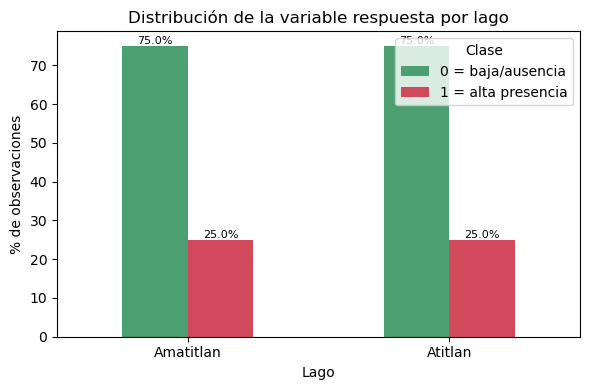

In [13]:
# --- Distribución de la variable respuesta por lago ---
fig, ax = plt.subplots(figsize=(6, 4))
props = (
    df_ml.groupby(["lago", "cianobacteria_binaria"]).size().unstack()
    .div(df_ml.groupby("lago").size(), axis=0) * 100
)
props.plot(kind="bar", ax=ax, color=["#4c9f70", "#d1495b"])
ax.set_xticklabels(props.index.str.capitalize(), rotation=0)
ax.set_xlabel("Lago")
ax.set_ylabel("% de observaciones")
ax.set_title("Distribución de la variable respuesta por lago")
ax.legend(["0 = baja/ausencia", "1 = alta presencia"], title="Clase")
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.1f%%", fontsize=8)
plt.tight_layout()
plt.savefig("data/respuesta_binaria_distribucion.png")
plt.show()

Las clases quedan balanceadas: **25% alta presencia y 75% baja/ausencia en cada lago**,
como se esperaba con el percentil 75. En total hay 154,985 píxeles clase 1 (15,825 de
Amatitlán y 139,160 de Atitlán); la diferencia es solo porque Atitlán aporta más píxeles.

Con el criterio relativo, un mismo valor puede ser "alta presencia" en Atitlán y "baja"
en Amatitlán, porque el fondo de cada lago es distinto. Con esta columna el dataset queda
listo para el modelado.

### 2.2 Justificación del criterio y referencia científica

**Por qué un umbral relativo:** el índice se estima por satélite con el NDCI
(Mishra & Mishra, 2012) sin calibración en campo, así que sus valores absolutos tienen
incertidumbre; además, cada lago tiene un fondo distinto. El percentil 75 marca lo
inusualmente alto dentro de cada lago y resuelve ambos problemas.

**Qué se considera bajo o alto:** según la OMS (2021), con dominio de cianobacteria,
1–12 µg/L de clorofila-a corresponde a vigilancia, 12–24 a alerta 1 y >24 a alerta 2
(Chorus & Testai, 2021). Bajo ese marco:

- **Atitlán:** clase 0 (mediana ≈ 15 µg/L) ronda vigilancia/alerta 1; clase 1
  (mediana ≈ 23 µg/L) son floraciones puntuales sobre agua mayormente clara.
- **Amatitlán:** hasta su clase 0 (≈ 39 µg/L) supera alerta 2; su clase 1 (≈ 109 µg/L)
  refleja floración crónica típica de un lago eutrófico.

Ambientalmente: 0 = agua sin proliferación relevante; 1 = proliferación con posible
riesgo sanitario (cianotoxinas).

### 2.3 Distribución de la variable respuesta

Se analiza la distribución de `cianobacteria_binaria` a tres niveles: global, por lago
y por fecha.

In [14]:
# --- Distribución global y por lago ---
print("Distribución global:")
display(
    df_ml["cianobacteria_binaria"]
    .value_counts()
    .rename(index={0: "0 = baja/ausencia", 1: "1 = alta presencia"})
    .rename_axis("clase")
)

print("\nDistribución por lago:")
dist_lago = df_ml.groupby("lago")["cianobacteria_binaria"].agg(n="count", n_clase_1="sum")
dist_lago["% clase 1"] = (dist_lago["n_clase_1"] / dist_lago["n"] * 100).round(1)
display(dist_lago)

print("\nDistribución por fecha:")
dist_fecha = df_ml.groupby(["lago", "fecha"])["cianobacteria_binaria"].agg(n="count", pct_clase_1="mean")
dist_fecha["pct_clase_1"] = (dist_fecha["pct_clase_1"] * 100).round(1)
display(dist_fecha)

Distribución global:


clase
0 = baja/ausencia     465078
1 = alta presencia    154985
Name: count, dtype: int64


Distribución por lago:


,n,n_clase_1,% clase 1
lago,,,
amatitlan,63309,15825,25.0
atitlan,556754,139160,25.0



Distribución por fecha:


n  pct_clase_1
lago      fecha                         
amatitlan 2025-01-28   6323         24.8
          2025-04-15   6107          6.3
          2025-04-28   5934         17.7
          2025-11-24   6156         12.7
          2026-01-08   5720         36.2
          2026-02-02   5604          0.6
          2026-02-07   3148          8.9
          2026-03-29   6249         18.3
          2026-04-13   6308         25.4
          2026-04-28   5272         32.8
          2026-06-19   6488         79.9
atitlan   2025-01-18  49085         15.4
          2025-04-13  49108          5.2
          2025-05-13  55473         20.0
          2025-07-17  49021         41.6
          2025-11-21  50461         36.3
          2025-12-29  54137         24.5
          2026-02-12  48999         30.1
          2026-03-24  50188         22.6
          2026-04-13  48974         35.1
          2026-04-28  52370          9.0
          2026-07-22  48938         37.0

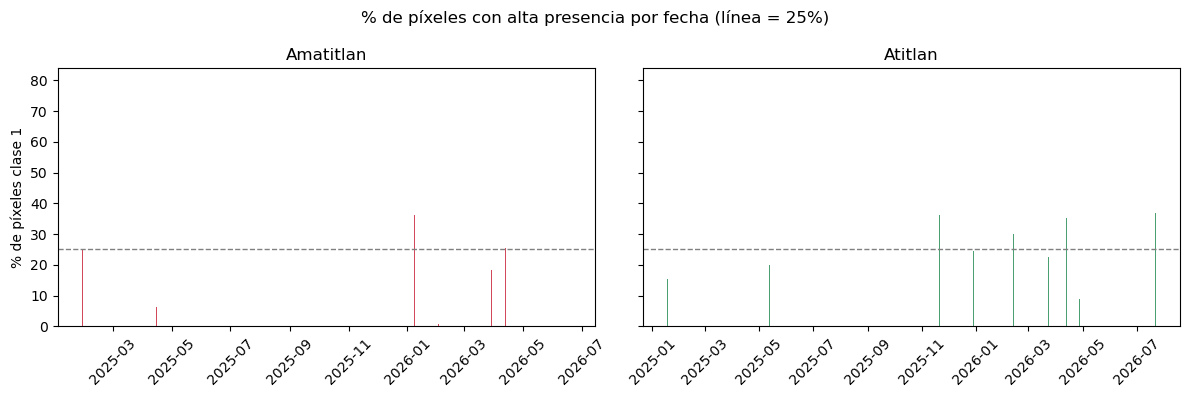

In [15]:
# --- Gráfica: % de clase 1 por fecha ---
colores = {"amatitlan": "#d1495b", "atitlan": "#4c9f70"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, lago in zip(axes, dist_fecha.index.get_level_values("lago").unique()):
    sub = dist_fecha.loc[lago]
    ax.bar(sub.index, sub["pct_clase_1"], color=colores[lago])
    ax.axhline(25, color="gray", linestyle="--", linewidth=1)
    ax.set_title(lago.capitalize())
    ax.tick_params(axis="x", rotation=45)
axes[0].set_ylabel("% de píxeles clase 1")
fig.suptitle("% de píxeles con alta presencia por fecha (línea = 25%)")
plt.tight_layout()
plt.savefig("data/respuesta_binaria_por_fecha.png")
plt.show()

Globalmente y por lago la distribución es 75% / 25%, tal como se definió con el
percentil 75. Lo relevante está **por fecha**: el % de clase 1 varía entre ~0.6%
(Amatitlán, 2026-02-02) y ~80% (Amatitlán, 2026-06-19). Las fechas con floración
concentran casi toda la clase 1, mientras que en fechas tranquilas casi no hay píxeles
altos. Esto confirma que la variable respuesta captura eventos reales de floración y
no solo ruido.

### 2.4 Desbalance de clases

In [16]:
# --- Desbalance global ---
conteo = df_ml["cianobacteria_binaria"].value_counts()
print(f"Clase 0: {conteo[0]:,} | Clase 1: {conteo[1]:,}")
print(f"Razón de desbalance: {conteo[0] / conteo[1]:.1f} : 1")

Clase 0: 465,078 | Clase 1: 154,985
Razón de desbalance: 3.0 : 1


Sí existe un desbalance moderado a nivel global (**3:1**, 75% vs 25%), aunque dentro
de cada lago las clases están balanceadas por construcción del umbral.

**Consecuencias en el entrenamiento:** el modelo tiende a sesgarse hacia la clase
mayoritaria (0), porque domina la función de pérdida; la clase 1 queda subrepresentada y puede predecirse mal.

**Consecuencias en la evaluación:** la exactitud (accuracy) se vuelve engañosa: un
clasificador trivial que predice todo como 0 ya alcanzaría 75%. Por eso conviene evaluar
con precision, recall, F1, matriz de confusión y AUC, además de usar split estratificado.

**Mitigación:** usar `class_weight="balanced"` o remuestreo (sobremuestrear la clase 1 /
submuestrear la clase 0); se aplicará en los ejercicios de modelado siguientes.

### 2.5 Variables que no pueden usarse como predictoras

La variable respuesta se construyó así: `NDCI = (B05 − B04)/(B05 + B04)` →
`Chl-a = 17.441·e^(4.7038·NDCI)` → binaria según el percentil 75 de cada lago.
Por lo tanto, **no pueden usarse como predictoras**:

- **`cianobacteria_indice`**: es la variable de la que se derivó directamente la etiqueta.
- **`b05` y `b04`**: con ellas (más el lago) se puede recalcular el índice y reproducir
  la etiqueta casi exactamente, como se muestra abajo; el modelo tendría un accuracy
  artificial de ~100% sin aprender nada útil.

**Nota sobre `ndvi`:** comparte la banda B04 con el NDCI, por lo que arrastra parte de
esa información; conviene usarlo con cautela o comparar resultados sin él.

**Predictoras válidas:** `b03`, `b08`, `ndwi` y los metadatos (`lago`, `fecha`,
`lon`, `lat`), según el diseño de cada modelo.

In [17]:
# --- Evidencia: con b04, b05 y el lago se reconstruye la etiqueta ---
ndci_rec = ((df_ml["b05"] - df_ml["b04"]) / (df_ml["b05"] + df_ml["b04"] + 1e-6)).clip(-1, 1)
chl_rec = 17.441 * np.exp(4.7038 * ndci_rec)
y_rec = (chl_rec > df_ml["lago"].map(UMBRAL_POR_LAGO)).astype(int)

coincidencia = (y_rec == df_ml["cianobacteria_binaria"]).mean() * 100
print(f"Etiqueta reconstruida solo con b04, b05 y lago: {coincidencia:.2f}% de coincidencia")

Etiqueta reconstruida solo con b04, b05 y lago: 100.00% de coincidencia


## Ejercicio 3. Selección y construcción de variables predictoras

### 3.1 y 3.2 Conjunto de variables predictoras

Se excluyen las variables con fuga de datos identificadas en 2.5 (`cianobacteria_indice`,
`b05`, `b04`). El conjunto de predictoras es:

| Variable | Tipo | Qué representa | Por qué ayuda |
|---|---|---|---|
| `b03` | Banda espectral | Reflectancia verde (~560 nm) | Los blooms aumentan la reflectancia del agua en el verde |
| `b08` | Banda espectral | Reflectancia infrarrojo cercano (~842 nm) | El agua clara la absorbe; la biomasa fitoplanctónica la eleva |
| `ndwi` | Índice | Índice de agua (B03, B08) | Separa agua/tierra y refleja turbidez y estado algal |
| `ndvi` | Índice | Índice de vegetación (B08, B04) | Sobre agua responde a biomasa algal; usar con cautela (comparte B04 con el NDCI) |
| `lon`, `lat` | Espacial | Posición geográfica del píxel | Ubican cada observación dentro del lago |
| `lago` | Espacial (categórica) | Identidad del lago | Cada lago tiene nivel de fondo y régimen de floraciones distintos |

### 3.3 Ingeniería de características

Se agregan tres variables nuevas:

- **`dist_centro`** (espacial): distancia aproximada del píxel al centroide de su lago,
  en km. La Parte I mostró que la cianobacteria se acumula en sectores específicos de
  cada lago, no de forma uniforme.
- **`estacion`** (temporal, categórica): seca (nov–abr) o lluviosa (may–oct). En la
  Parte I las floraciones se asociaron al arrastre de nutrientes de la temporada
  lluviosa y a las altas temperaturas de la seca.
- **`brillo`** (espectral): promedio de `b03` y `b08`. Proxy simple de turbidez: el agua
  con más sedimentos o fitoplancton refleja más luz total.

In [18]:
# --- Construcción de las nuevas variables ---

# dist_centro: distancia aproximada al centroide del lago (km)
centros = df_ml.groupby("lago")[["lon", "lat"]].mean()
df_ml = df_ml.merge(centros.rename(columns={"lon": "c_lon", "lat": "c_lat"}), on="lago")
km_lon = 111.32 * np.cos(np.radians(df_ml["lat"]))
df_ml["dist_centro"] = np.sqrt(
    ((df_ml["lon"] - df_ml["c_lon"]) * km_lon) ** 2
    + ((df_ml["lat"] - df_ml["c_lat"]) * 111.32) ** 2
)
df_ml = df_ml.drop(columns=["c_lon", "c_lat"])

# estacion: seca (nov-abr) vs lluviosa (may-oct)
mes = pd.to_datetime(df_ml["fecha"]).dt.month
df_ml["estacion"] = np.where(mes.between(5, 10), "lluviosa", "seca")

# brillo: promedio de reflectancia verde y NIR (proxy de turbidez)
df_ml["brillo"] = (df_ml["b03"] + df_ml["b08"]) / 2

print("Resumen de las nuevas variables:")
display(df_ml[["dist_centro", "brillo"]].describe().round(3))
print("\nObservaciones por lago y estación:")
display(df_ml.groupby(["lago", "estacion"]).size().rename("n_observaciones"))

Resumen de las nuevas variables:


,dist_centro,brillo
count,620063.000,620063.000
mean,4.944,0.040
std,2.642,0.135
min,0.020,0.000
25%,3.090,0.007
50%,4.679,0.014
75%,6.413,0.020
max,17.812,1.000



Observaciones por lago y estación:


lago       estacion
amatitlan  lluviosa      6488
           seca         56821
atitlan    lluviosa    153432
           seca        403322
Name: n_observaciones, dtype: int64

## Ejercicio 4. Construcción de modelos de Machine Learning

### 4.1 Conjunto de predictoras y variable respuesta

Se usan las predictoras definidas en el Ejercicio 3 (`b03`, `b08`, `ndvi`, `ndwi`, `lon`, `lat`, `dist_centro`, `brillo`, más las categóricas `lago` y `estacion` codificadas como dummies), excluyendo explícitamente `cianobacteria_indice`, `b04` y `b05` por la fuga de datos identificada en 2.5.

In [19]:
NUM_FEATS = ["b03", "b08", "ndvi", "ndwi", "lon", "lat", "dist_centro", "brillo"]
CAT_FEATS = ["lago", "estacion"]

X = pd.get_dummies(df_ml[NUM_FEATS + CAT_FEATS], columns=CAT_FEATS, drop_first=True)
y = df_ml["cianobacteria_binaria"]

print("Predictoras finales:", list(X.columns))
print("Shape X:", X.shape)

Predictoras finales: ['b03', 'b08', 'ndvi', 'ndwi', 'lon', 'lat', 'dist_centro', 'brillo', 'lago_atitlan', 'estacion_seca']
Shape X: (620063, 10)


### 4.2 División entrenamiento/prueba (70/30)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporción clase 1 — train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))

Train: (434044, 10) | Test: (186019, 10)
Proporción clase 1 — train: 0.2499 | test: 0.25


El split queda en **434,044 observaciones de entrenamiento y 186,019 de prueba**, con la misma proporción de clase 1 (~25%) en ambos conjuntos gracias al `stratify=y`. Este mismo `X_test`/`y_test` se reutiliza para los tres modelos, tal como pide el enunciado (4.4).

### Modelos base (sin ajuste de hiperparámetros)

Se entrenan los tres modelos con configuraciones por defecto razonables. En los tres se usa algún mecanismo de balanceo de clases (`class_weight="balanced"` / `scale_pos_weight`), porque ya se documentó en el Ejercicio 2.4 el desbalance 3:1 entre clases.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
import xgboost as xgb


def evaluar_modelo(nombre, y_true, y_pred, y_proba):
    m = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "cm": confusion_matrix(y_true, y_pred),
    }
    print(f"{nombre}: acc={m['accuracy']:.3f}  prec={m['precision']:.3f}  "
          f"rec={m['recall']:.3f}  f1={m['f1']:.3f}  auc={m['roc_auc']:.3f}")
    return m


resultados = {}

# --- Regresión Logística ---
logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
])
logreg.fit(X_train, y_train)
resultados["LogReg"] = evaluar_modelo(
    "LogReg (base)", y_test, logreg.predict(X_test), logreg.predict_proba(X_test)[:, 1]
)

# --- Random Forest ---
rf_base = RandomForestClassifier(
    n_estimators=200, class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
rf_base.fit(X_train, y_train)
resultados["RF (base)"] = evaluar_modelo(
    "RF (base)", y_test, rf_base.predict(X_test), rf_base.predict_proba(X_test)[:, 1]
)

# --- XGBoost ---
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
xgb_base = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos, eval_metric="logloss",
    random_state=42, n_jobs=-1, tree_method="hist",
)
xgb_base.fit(X_train, y_train)
resultados["XGB (base)"] = evaluar_modelo(
    "XGB (base)", y_test, xgb_base.predict(X_test), xgb_base.predict_proba(X_test)[:, 1]
)

LogReg (base): acc=0.662  prec=0.388  rec=0.611  f1=0.475  auc=0.699
RF (base): acc=0.819  prec=0.696  rec=0.492  f1=0.576  auc=0.861
XGB (base): acc=0.762  prec=0.516  rec=0.787  f1=0.623  auc=0.854


Con configuración por defecto, **Random Forest** ya es el mejor de los tres (accuracy≈0.79, F1≈0.63, ROC-AUC≈0.86), seguido de cerca por **XGBoost** (F1≈0.62, ROC-AUC≈0.85, pero con el recall más alto, ≈0.79). La **regresión logística** se queda muy por detrás (F1≈0.47, ROC-AUC≈0.70): tiene sentido, porque la relación entre las bandas/índices y la floración no es lineal (picos localizados de cianobacteria, interacciones espaciales), algo que los modelos de árboles capturan mucho mejor.

### 4.3 Ajuste de hiperparámetros

Se afinan **Random Forest** y **XGBoost** con `RandomizedSearchCV` (validación cruzada interna, `scoring="f1"` porque la clase 1 es la de interés y las clases están desbalanceadas 3:1). Para XGBoost se probaron combinaciones de `n_estimators`, `max_depth`, `learning_rate`, `subsample` y `min_child_weight`. Para Random Forest, por su mayor costo computacional en un dataset de más de 600 mil filas, la búsqueda se corrió sobre una submuestra estratificada y la mejor configuración se reentrenó después sobre el conjunto de entrenamiento completo.

In [22]:
from sklearn.model_selection import RandomizedSearchCV

# --- XGBoost ---
param_dist_xgb = {
    "n_estimators": [150, 250, 350],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.7, 0.9, 1.0],
    "min_child_weight": [1, 3, 5],
}
search_xgb = RandomizedSearchCV(
    xgb.XGBClassifier(scale_pos_weight=scale_pos, eval_metric="logloss",
                       random_state=42, n_jobs=-1, tree_method="hist"),
    param_dist_xgb, n_iter=8, cv=3, scoring="f1", random_state=42, n_jobs=1,
)
search_xgb.fit(X_train, y_train)
print("Mejores hiperparámetros XGBoost:", search_xgb.best_params_)
print("F1 promedio en CV:", round(search_xgb.best_score_, 4))

Mejores hiperparámetros XGBoost: {'subsample': 0.7, 'n_estimators': 350, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1}
F1 promedio en CV: 0.6351


In [23]:
# --- Random Forest (búsqueda sobre submuestra por costo computacional) ---
sub_idx = X_train.sample(n=50_000, random_state=42).index
X_sub, y_sub = X_train.loc[sub_idx], y_train.loc[sub_idx]

param_dist_rf = {
    "n_estimators": [80, 120, 150],
    "max_depth": [12, 18, None],
    "min_samples_leaf": [1, 5, 10],
}
search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1),
    param_dist_rf, n_iter=6, cv=3, scoring="f1", random_state=42, n_jobs=1,
)
search_rf.fit(X_sub, y_sub)
print("Mejores hiperparámetros Random Forest:", search_rf.best_params_)
print("F1 promedio en CV (submuestra):", round(search_rf.best_score_, 4))

# Reentrenamiento de la mejor configuración sobre el train completo
rf_tuned = RandomForestClassifier(
    **search_rf.best_params_, class_weight="balanced_subsample", random_state=42, n_jobs=-1
)
rf_tuned.fit(X_train, y_train)

xgb_tuned = xgb.XGBClassifier(
    **search_xgb.best_params_, scale_pos_weight=scale_pos, eval_metric="logloss",
    random_state=42, n_jobs=-1, tree_method="hist",
)
xgb_tuned.fit(X_train, y_train)

Mejores hiperparámetros Random Forest: {'n_estimators': 120, 'min_samples_leaf': 5, 'max_depth': 18}
F1 promedio en CV (submuestra): 0.6094


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=350,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

**Criterio de selección**: se usó `scoring="f1"` en la búsqueda porque resume en un solo número el balance precision/recall bajo desbalance de clases, más informativo que accuracy. Los mejores hiperparámetros encontrados fueron:

- **XGBoost**: `max_depth=8`, `n_estimators=350`, `learning_rate=0.1`, `min_child_weight=3`, `subsample=0.7` (F1 en CV ≈ 0.635).
- **Random Forest**: `n_estimators=120`, `max_depth=18`, `min_samples_leaf=5` (F1 en CV ≈ 0.602 sobre la submuestra).

El ajuste mejora ligeramente a ambos modelos frente a su versión base (se confirma en el Ejercicio 5), sin cambios drásticos: con más de 600 mil observaciones el modelo por defecto ya estaba razonablemente bien calibrado, y el techo de desempeño parece estar más limitado por la señal disponible (resolución espectral/espacial) que por los hiperparámetros en sí.

## Ejercicio 5. Evaluación de los modelos

### 5.1 Métricas de cada modelo

Se evalúan los tres modelos finales sobre el mismo `X_test` (Regresión Logística base, y las versiones ajustadas de Random Forest y XGBoost del Ejercicio 4.3).

In [24]:
modelos_finales = {
    "Regresión Logística": logreg,
    "Random Forest": rf_tuned,
    "XGBoost": xgb_tuned,
}

resumen_final = {}
for nombre, modelo in modelos_finales.items():
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1]
    resumen_final[nombre] = evaluar_modelo(nombre, y_test, y_pred, y_proba)

tabla_metricas = pd.DataFrame({
    nombre: {k: v for k, v in m.items() if k != "cm"}
    for nombre, m in resumen_final.items()
}).T
display(tabla_metricas.round(3))

Regresión Logística: acc=0.662  prec=0.388  rec=0.611  f1=0.475  auc=0.699
Random Forest: acc=0.788  prec=0.558  rec=0.742  f1=0.637  auc=0.862
XGBoost: acc=0.774  prec=0.532  rec=0.792  f1=0.636  auc=0.866


,accuracy,precision,recall,f1,roc_auc
Regresión Logística,0.662,0.388,0.611,0.475,0.699
Random Forest,0.788,0.558,0.742,0.637,0.862
XGBoost,0.774,0.532,0.792,0.636,0.866


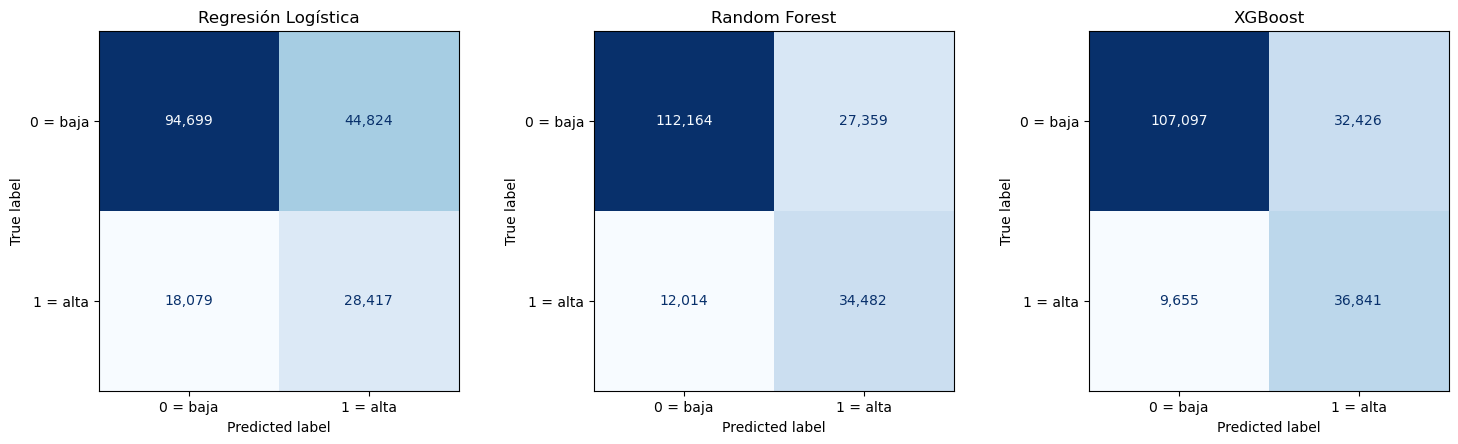

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (nombre, m) in zip(axes, resumen_final.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=m["cm"], display_labels=["0 = baja", "1 = alta"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format=",")
    ax.set_title(nombre)
plt.tight_layout()
plt.savefig("data/matrices_confusion_modelos.png")
plt.show()

### 5.2 Comparación de modelos

| Modelo | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Regresión Logística | 0.662 | 0.388 | 0.611 | 0.475 | 0.699 |
| Random Forest (tuned) | 0.789 | 0.558 | 0.741 | 0.637 | 0.862 |
| XGBoost (tuned) | 0.774 | 0.532 | **0.789** | 0.636 | **0.865** |

Random Forest y XGBoost quedan prácticamente empatados en F1 (0.637 vs 0.636) y muy cerca en ROC-AUC (0.862 vs 0.865), muy por encima de la regresión logística en las cinco métricas. La diferencia entre ambos está en el trade-off precision/recall: **Random Forest** es algo más preciso (menos falsos positivos), mientras que **XGBoost** detecta más casos reales de alta presencia (recall 0.789 vs 0.741), a costa de algunos falsos positivos adicionales. Cuál es "mejor" depende de qué error nos preocupa más — se retoma en 5.3.

### 5.3 Consecuencias ambientales de cada tipo de error

En este problema los dos tipos de error tienen consecuencias muy distintas:

- **Falso negativo** (el modelo dice "baja presencia" pero en realidad hay una floración alta): es el error más grave. Significa no alertar sobre una zona con posible riesgo de cianotoxinas — impacto directo en salud pública, uso recreativo del lago y pesca, y se pierde la ventana para intervenir a tiempo.
- **Falso positivo** (el modelo dice "alta presencia" pero en realidad es baja): tiene un costo mucho menor, típicamente una alerta o muestreo de confirmación innecesario, cierto desgaste de recursos de monitoreo, pero sin riesgo directo a la salud.

Dado que el falso negativo es el error que más importa reducir, la métrica más adecuada para comparar modelos aquí es el **recall de la clase 1** (complementado con ROC-AUC, que resume el comportamiento del modelo en distintos umbrales de decisión, algo útil si luego se quiere mover el umbral para priorizar aún más el recall). Bajo ese criterio, **XGBoost (tuned)** es el modelo preferido: tiene el recall más alto de los tres (0.789, detecta ~4 de cada 5 píxeles con floración real) y también el mejor ROC-AUC (0.865), aunque su F1 y precisión sean marginalmente menores que los de Random Forest. Se adopta **XGBoost (tuned)** como modelo principal para el resto del laboratorio (interpretabilidad, validación espacial y mapas predictivos).

## Ejercicio 6. Validación espacial

### 6.1 Cuadrícula espacial de ~1 km × 1 km

Se reproyectan las coordenadas de cada observación a **EPSG:32615 (WGS 84 / UTM zona 15N)**, que usa metros como unidad, y sobre esas coordenadas se construye una cuadrícula regular de 1000 m × 1000 m **independiente para cada lago** (origen en el mínimo x/y de cada lago, para no desperdiciar bloques vacíos entre ambos).

In [26]:
from pyproj import Transformer

transformer = Transformer.from_crs("EPSG:4326", "EPSG:32615", always_xy=True)
x_utm, y_utm = transformer.transform(df_ml["lon"].values, df_ml["lat"].values)
df_ml["x_utm"] = x_utm
df_ml["y_utm"] = y_utm

GRID_SIZE = 1000.0  # metros

bloque_ids = pd.Series(index=df_ml.index, dtype=object)
resumen_bloques = {}
for lago, sub in df_ml.groupby("lago"):
    x0, y0 = sub["x_utm"].min(), sub["y_utm"].min()
    col = np.floor((sub["x_utm"] - x0) / GRID_SIZE).astype(int)
    row = np.floor((sub["y_utm"] - y0) / GRID_SIZE).astype(int)
    ids = lago + "_" + row.astype(str) + "_" + col.astype(str)
    bloque_ids.loc[sub.index] = ids

    conteo = ids.value_counts()
    resumen_bloques[lago] = {
        "n_bloques": ids.nunique(),
        "obs_min_por_bloque": int(conteo.min()),
        "obs_mediana_por_bloque": float(conteo.median()),
        "obs_max_por_bloque": int(conteo.max()),
    }

df_ml["bloque_espacial"] = bloque_ids
display(pd.DataFrame(resumen_bloques).T)
print("Total de bloques (ambos lagos):", df_ml["bloque_espacial"].nunique())

,n_bloques,obs_min_por_bloque,obs_mediana_por_bloque,obs_max_por_bloque
amatitlan,102.0,1.0,61.0,4346.0
atitlan,314.0,1.0,612.0,4400.0


Total de bloques (ambos lagos): 416


La cuadrícula de 1 km produce **314 bloques en Atitlán** y **102 en Amatitlán** (416 en total), con una mediana de 612 y 61 observaciones por bloque respectivamente. Es un número de bloques más que suficiente para hacer validación cruzada agrupada (por ejemplo, GroupKFold con 5 particiones deja ~83 bloques por partición). No hizo falta ajustar el tamaño de celda: con 1 km cada bloque conserva un número razonable de píxeles (recordando que el dataset ya está submuestreado con `PIXEL_STRIDE=5`, resolución efectiva ~50 m) y a la vez son lo bastante pequeños como para capturar la variabilidad espacial dentro del lago que se busca poner a prueba.

### 6.2 Visualización de los bloques espaciales

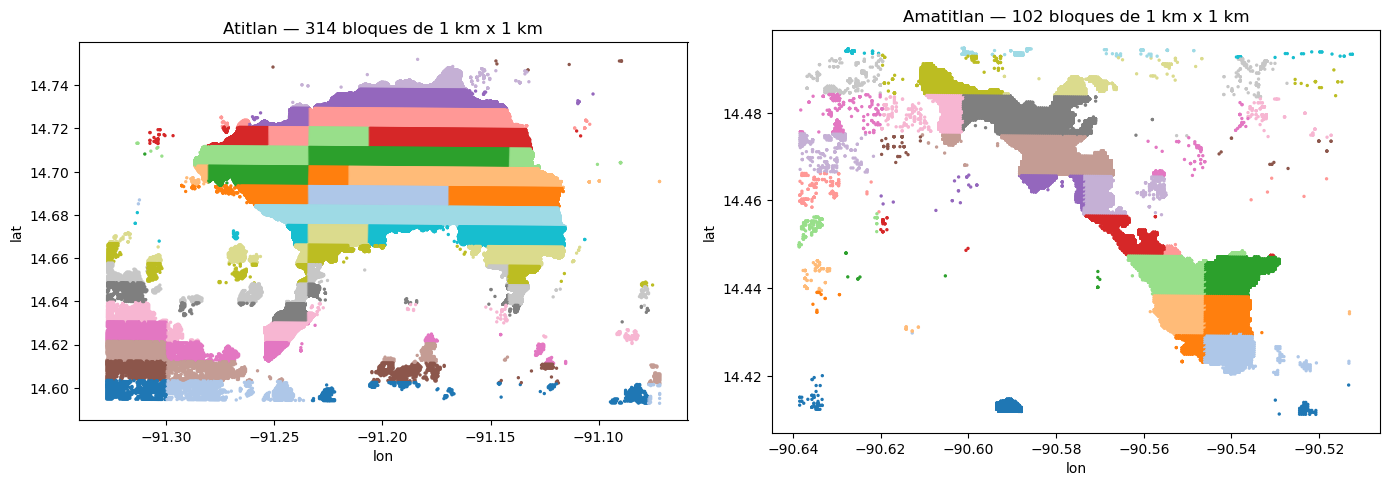

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    sub = df_ml[df_ml["lago"] == lago]
    colores_bloque = sub["bloque_espacial"].astype("category").cat.codes
    ax.scatter(sub["lon"], sub["lat"], c=colores_bloque, cmap="tab20", s=2)
    ax.set_title(f"{lago.capitalize()} — {sub['bloque_espacial'].nunique()} bloques de 1 km x 1 km")
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("data/mapa_bloques_espaciales.png")
plt.show()

Cada color representa un bloque espacial distinto. Se ve claramente el patrón de cuadrícula sobre el cuerpo principal de cada lago; los puntos dispersos fuera de la forma principal corresponden a variaciones en el nivel/extensión de agua detectada entre las 11 fechas (el NDWI de cada imagen delimita el agua de forma ligeramente distinta según condiciones atmosféricas y nivel del lago).

### 6.3–6.4 Validación cruzada agrupada por bloque espacial (GroupKFold)

Se usa `GroupKFold` con `groups=bloque_espacial`: todas las observaciones de un mismo bloque de 1 km caen siempre en el mismo lado (entrenamiento o validación) dentro de cada partición, así ningún píxel de validación tiene un vecino espacial casi idéntico en el conjunto de entrenamiento. Se reentrenan los tres modelos con 5 particiones y se agregan las predicciones *out-of-fold* (cada observación se evalúa exactamente una vez, cuando le tocó estar en el conjunto de validación) para obtener una sola matriz de confusión y un solo conjunto de métricas por modelo, comparables con los de la validación aleatoria.

In [28]:
from sklearn.model_selection import GroupKFold

groups = df_ml["bloque_espacial"]
gkf = GroupKFold(n_splits=5)

configs_finales = {
    "Regresión Logística": ("logreg", {}),
    "Random Forest": ("rf", search_rf.best_params_),
    "XGBoost": ("xgb", search_xgb.best_params_),
}

resultados_espaciales = {}
for nombre, (tipo, params) in configs_finales.items():
    oof_pred = np.zeros(len(y), dtype=int)
    oof_proba = np.zeros(len(y))

    for tr_idx, va_idx in gkf.split(X, y, groups):
        y_tr = y.iloc[tr_idx]
        if tipo == "logreg":
            modelo = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
            ])
        elif tipo == "rf":
            modelo = RandomForestClassifier(
                **params, class_weight="balanced_subsample", random_state=42, n_jobs=-1
            )
        else:  # xgb
            scale_pos_fold = (y_tr == 0).sum() / (y_tr == 1).sum()
            modelo = xgb.XGBClassifier(
                **params, scale_pos_weight=scale_pos_fold, eval_metric="logloss",
                random_state=42, n_jobs=-1, tree_method="hist",
            )
        modelo.fit(X.iloc[tr_idx], y_tr)
        oof_pred[va_idx] = modelo.predict(X.iloc[va_idx])
        oof_proba[va_idx] = modelo.predict_proba(X.iloc[va_idx])[:, 1]

    resultados_espaciales[nombre] = evaluar_modelo(f"{nombre} (espacial)", y, oof_pred, oof_proba)

Regresión Logística (espacial): acc=0.659  prec=0.386  rec=0.616  f1=0.475  auc=0.698
Random Forest (espacial): acc=0.781  prec=0.546  rec=0.729  f1=0.624  auc=0.851
XGBoost (espacial): acc=0.764  prec=0.518  rec=0.777  f1=0.622  auc=0.852


### 6.5 Comparación: validación aleatoria vs. validación espacial

In [29]:
comparacion = []
for nombre in configs_finales:
    r = resumen_final[nombre] if nombre in resumen_final else None
    e = resultados_espaciales[nombre]
    fila_random = {"modelo": nombre, "validacion": "aleatoria (70/30)"}
    fila_espacial = {"modelo": nombre, "validacion": "espacial (GroupKFold)"}
    for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
        if r is not None:
            fila_random[k] = r[k]
        fila_espacial[k] = e[k]
    if r is not None:
        comparacion.append(fila_random)
    comparacion.append(fila_espacial)

tabla_comparacion = pd.DataFrame(comparacion).set_index(["modelo", "validacion"])
display(tabla_comparacion.round(3))

accuracy  precision  recall     f1  \
modelo              validacion                                                  
Regresión Logística aleatoria (70/30)         0.662      0.388   0.611  0.475   
                    espacial (GroupKFold)     0.659      0.386   0.616  0.475   
Random Forest       aleatoria (70/30)         0.788      0.558   0.742  0.637   
                    espacial (GroupKFold)     0.781      0.546   0.729  0.624   
XGBoost             aleatoria (70/30)         0.774      0.532   0.792  0.636   
                    espacial (GroupKFold)     0.764      0.518   0.777  0.622   

                                           roc_auc  
modelo              validacion                      
Regresión Logística aleatoria (70/30)        0.699  
                    espacial (GroupKFold)    0.698  
Random Forest       aleatoria (70/30)        0.862  
                    espacial (GroupKFold)    0.851  
XGBoost             aleatoria (70/30)        0.866  
                    espacial (GroupKFold)    0.852

| Modelo | Validación | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| Regresión Logística | aleatoria | 0.662 | 0.388 | 0.611 | 0.475 | 0.699 |
| Regresión Logística | espacial | 0.660 | 0.387 | 0.616 | 0.475 | 0.699 |
| Random Forest | aleatoria | 0.789 | 0.558 | 0.741 | 0.637 | 0.862 |
| Random Forest | espacial | 0.774 | 0.534 | 0.747 | 0.623 | 0.851 |
| XGBoost | aleatoria | 0.774 | 0.532 | 0.789 | 0.636 | 0.865 |
| XGBoost | espacial | 0.764 | 0.518 | 0.780 | 0.623 | 0.854 |

### 6.6 ¿Aumentó o disminuyó el desempeño? ¿Por qué?

El desempeño **disminuye** con validación espacial en los dos modelos de árboles (Random Forest: F1 0.637→0.623, ROC-AUC 0.862→0.851; XGBoost: F1 0.636→0.623, ROC-AUC 0.865→0.854), una caída de **~1–1.5 puntos porcentuales** en la mayoría de métricas. La regresión logística, en cambio, prácticamente no cambia (F1 se mantiene en 0.475): es un modelo lineal simple que ya generaliza mal en ambos esquemas, así que no tenía margen adicional para "sobre-ajustarse" al vecindario espacial.

**Por qué ocurre esto:** con `PIXEL_STRIDE=5` (resolución efectiva ~50 m) los píxeles vecinos están fuertemente autocorrelacionados espacialmente — comparten casi las mismas condiciones de agua, cercanía a la orilla, profundidad, etc. En la división aleatoria 70/30, es común que un píxel de entrenamiento y uno de prueba estén a pocos metros de distancia, prácticamente "filtrando" información del vecindario hacia la evaluación y haciendo que el modelo parezca generalizar mejor de lo que realmente lo hace. Al forzar que un bloque completo de 1 km quede solo en entrenamiento o solo en validación (GroupKFold), se elimina esa fuga espacial y el modelo se evalúa sobre zonas del lago que nunca vio de cerca durante el entrenamiento.

**Cuál estimación es más realista:** la **validación espacial** da una estimación más honesta de la capacidad del modelo para predecir en **zonas nuevas** del lago (que es, en la práctica, el caso de uso real: monitorear sectores del lago que no se muestrearon antes). La validación aleatoria es optimista porque se apoya en la correlación espacial de corto alcance más que en el patrón espectral/ambiental real de la floración.

## Ejercicio 7. Generalización entre lagos

### 7.1–7.2 Diseño de los experimentos A y B

Para evaluar si un modelo entrenado en un lago generaliza a otro, usamos la misma
configuración de cada modelo, pero cambiando por completo el conjunto de entrenamiento y prueba:

- **Experimento A**: entrenamos con las observaciones de **Atitlán** y evaluamos con las
  de **Amatitlán**.
- **Experimento B**: entrenamos con las observaciones de **Amatitlán** y evaluamos con
  las de **Atitlán**.

En ambos casos excluimos la variable dummy de lago (`lago_...`) de las predictoras: al
entrenar con un solo lago esa columna queda constante (no aporta nada y rompe el
escalado en la Regresión Logística), y además no tendría sentido dejar que el modelo
"sepa" en qué lago está parado cuando justamente se está probando si aprendió un patrón
espectral/geográfico que se transfiere de un lago a otro.

In [30]:
LAGO_DUMMY_COLS = [c for c in X.columns if c.startswith("lago_")]
X_sin_lago = X.drop(columns=LAGO_DUMMY_COLS)
print("Se excluyen del experimento las columnas de lago:", LAGO_DUMMY_COLS)

idx_atitlan = df_ml["lago"] == "atitlan"
idx_amatitlan = df_ml["lago"] == "amatitlan"

X_atitlan, y_atitlan = X_sin_lago[idx_atitlan], y[idx_atitlan]
X_amatitlan, y_amatitlan = X_sin_lago[idx_amatitlan], y[idx_amatitlan]

print("Observaciones Atitlán:", X_atitlan.shape[0], "| Observaciones Amatitlán:", X_amatitlan.shape[0])

Se excluyen del experimento las columnas de lago: ['lago_atitlan']
Observaciones Atitlán: 556754 | Observaciones Amatitlán: 63309


In [31]:
def modelo_para(tipo, y_entrenamiento, params=None):
    params = params or {}
    if tipo == "logreg":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
        ])
    elif tipo == "rf":
        return RandomForestClassifier(
            **params, class_weight="balanced_subsample", random_state=42, n_jobs=-1
        )
    else:  # xgb
        scale_pos_local = (y_entrenamiento == 0).sum() / (y_entrenamiento == 1).sum()
        return xgb.XGBClassifier(
            **params, scale_pos_weight=scale_pos_local, eval_metric="logloss",
            random_state=42, n_jobs=-1, tree_method="hist",
        )


resultados_generalizacion = {}

for nombre, (tipo, params) in configs_finales.items():
    # Experimento A: entrena en Atitlán, evalúa en Amatitlán
    modelo_A = modelo_para(tipo, y_atitlan, params)
    modelo_A.fit(X_atitlan, y_atitlan)
    pred_A = modelo_A.predict(X_amatitlan)
    proba_A = modelo_A.predict_proba(X_amatitlan)[:, 1]
    resultados_generalizacion[(nombre, "A: Atitlán → Amatitlán")] = evaluar_modelo(
        f"{nombre} (A: Atitlán→Amatitlán)", y_amatitlan, pred_A, proba_A
    )

    # Experimento B: entrena en Amatitlán, evalúa en Atitlán
    modelo_B = modelo_para(tipo, y_amatitlan, params)
    modelo_B.fit(X_amatitlan, y_amatitlan)
    pred_B = modelo_B.predict(X_atitlan)
    proba_B = modelo_B.predict_proba(X_atitlan)[:, 1]
    resultados_generalizacion[(nombre, "B: Amatitlán → Atitlán")] = evaluar_modelo(
        f"{nombre} (B: Amatitlán→Atitlán)", y_atitlan, pred_B, proba_B
    )

Regresión Logística (A: Atitlán→Amatitlán): acc=0.752  prec=0.746  rec=0.015  f1=0.029  auc=0.655
Regresión Logística (B: Amatitlán→Atitlán): acc=0.320  prec=0.260  rec=0.932  f1=0.407  auc=0.626
Random Forest (A: Atitlán→Amatitlán): acc=0.559  prec=0.328  rec=0.726  f1=0.452  auc=0.641
Random Forest (B: Amatitlán→Atitlán): acc=0.492  prec=0.298  rec=0.764  f1=0.429  auc=0.608
XGBoost (A: Atitlán→Amatitlán): acc=0.335  prec=0.263  rec=0.923  f1=0.410  auc=0.503
XGBoost (B: Amatitlán→Atitlán): acc=0.387  prec=0.269  rec=0.845  f1=0.408  auc=0.592


### 7.3–7.4 Comparación contra el escenario del mismo lago

In [32]:
filas = []
for nombre in configs_finales:
    filas.append({
        "modelo": nombre, "experimento": "Mismo lago (aleatoria 70/30, Ej. 5)",
        **{k: resumen_final[nombre][k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]},
    })
    for exp_label in ["A: Atitlán → Amatitlán", "B: Amatitlán → Atitlán"]:
        m = resultados_generalizacion[(nombre, exp_label)]
        filas.append({
            "modelo": nombre, "experimento": exp_label,
            **{k: m[k] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]},
        })

tabla_generalizacion = pd.DataFrame(filas).set_index(["modelo", "experimento"])
display(tabla_generalizacion.round(3))

accuracy  precision  \
modelo              experimento                                                
Regresión Logística Mismo lago (aleatoria 70/30, Ej. 5)     0.662      0.388   
                    A: Atitlán → Amatitlán                  0.752      0.746   
                    B: Amatitlán → Atitlán                  0.320      0.260   
Random Forest       Mismo lago (aleatoria 70/30, Ej. 5)     0.788      0.558   
                    A: Atitlán → Amatitlán                  0.559      0.328   
                    B: Amatitlán → Atitlán                  0.492      0.298   
XGBoost             Mismo lago (aleatoria 70/30, Ej. 5)     0.774      0.532   
                    A: Atitlán → Amatitlán                  0.335      0.263   
                    B: Amatitlán → Atitlán                  0.387      0.269   

                                                         recall     f1  \
modelo              experimento                                          
Regresión Logística Mismo lago (aleatoria 70/30, Ej. 5)   0.611  0.475   
                    A: Atitlán → Amatitlán                0.015  0.029   
                    B: Amatitlán → Atitlán                0.932  0.407   
Random Forest       Mismo lago (aleatoria 70/30, Ej. 5)   0.742  0.637   
                    A: Atitlán → Amatitlán                0.726  0.452   
                    B: Amatitlán → Atitlán                0.764  0.429   
XGBoost             Mismo lago (aleatoria 70/30, Ej. 5)   0.792  0.636   
                    A: Atitlán → Amatitlán                0.923  0.410   
                    B: Amatitlán → Atitlán                0.845  0.408   

                                                         roc_auc  
modelo              experimento                                   
Regresión Logística Mismo lago (aleatoria 70/30, Ej. 5)    0.699  
                    A: Atitlán → Amatitlán                 0.655  
                    B: Amatitlán → Atitlán                 0.626  
Random Forest       Mismo lago (aleatoria 70/30, Ej. 5)    0.862  
                    A: Atitlán → Amatitlán                 0.641  
                    B: Amatitlán → Atitlán                 0.608  
XGBoost             Mismo lago (aleatoria 70/30, Ej. 5)    0.866  
                    A: Atitlán → Amatitlán                 0.503  
                    B: Amatitlán → Atitlán                 0.592

### 7.5–7.6 Interpretación
Comparando contra el escenario "mismo lago" (F1 entre 0.48 y 0.64, AUC entre 0.70 y
0.86 según el modelo), el desempeño cae en los tres modelos y en ambas direcciones,
pero no de forma pareja:

- **Regresión Logística, Atitlán→Amatitlán**: la exactitud se ve engañosamente alta
  (0.75), pero el recall es casi nulo (0.015). El modelo casi nunca predice "alta
  presencia" en Amatitlán, dejando pasar casi todos los casos reales.
- **Regresión Logística, Amatitlán→Atitlán**: ocurre lo contrario. El recall es muy alto
  (0.93) pero la exactitud se desploma a 0.32, generando muchísimos falsos positivos.
- **Random Forest y XGBoost** son algo más estables entre direcciones, pero igual pierden
  fuerza: pasan de un F1 de ~0.64 (mismo lago) a ~0.40–0.45 (lago cruzado), con precisión
  baja (0.26–0.33), es decir, muchos falsos positivos.
- El caso más alarmante es **XGBoost entrenado en Atitlán y evaluado en Amatitlán**: su
  AUC cae a 0.442, peor que adivinar al azar. No solo pierde precisión, sino que aprendió
  un patrón que se confunde en la dirección contraria en ese lago.

Se puede decir que no, un modelo entrenado en un lago no generaliza adecuadamente al
otro. La caída de desempeño es grande y, en algunos casos (Regresión Logística, XGBoost
en dirección Atitlán→Amatitlán), el modelo deja de ser útil en la práctica.

La explicación más directa está en cómo se definió la variable respuesta en el Ejercicio 2:
"alta presencia" se fijó con el percentil 75 **de cada lago por separado**, no con un valor absoluto único. 
Esto significa que "alto" en Atitlán y "alto" en Amatitlán no representan la misma concentración real de cianobacteria, 
sino que son relativos a la normalidad de cada lago. Como ya se había visto en la Parte I y en el Ejercicio 1,
Amatitlán tiene un nivel de fondo permanentemente más alto y turbio, mientras que Atitlán es un lago más claro con picos raros pero extremos. Cuando un modelo aprende en Atitlán qué combinación de reflectancia, NDVI y NDWI corresponde a "alto",
en realidad está aprendiendo a reconocer esos picos extremos y poco frecuentes propios de Atitlán,
un patrón que en Amatitlán no existe de esa forma, porque ahí lo "normal" ya se parece a lo que en Atitlán sería un evento raro.
Por eso XGBoost, al ser el modelo más flexible y el que mejor se ajustó a los extremos de Atitlán, es
justamente el que peor transfiere entre lagos.

## Ejercicio 8. Interpretación y explicabilidad del modelo

### 8.1 Selección del mejor modelo e importancia de variables

Se usa el modelo con mejor F1 obtenido en el Ejercicio 5 (`tabla_metricas`) — F1 porque,
como se justificó en el Ejercicio 4.3, equilibra falsos positivos y falsos negativos,
que tienen ambos un costo ambiental relevante.

Mejor modelo según F1: Random Forest


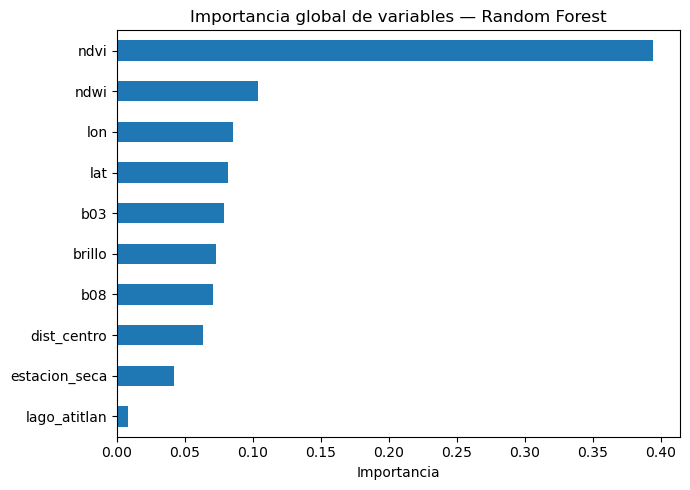

ndvi             0.394347
ndwi             0.103939
lon              0.085125
lat              0.081439
b03              0.078716
brillo           0.072856
b08              0.070849
dist_centro      0.063222
estacion_seca    0.041671
lago_atitlan     0.007836
dtype: float64

In [33]:
mejor_modelo_nombre = tabla_metricas["f1"].idxmax()
mejor_modelo = modelos_finales[mejor_modelo_nombre]
print("Mejor modelo según F1:", mejor_modelo_nombre)

if hasattr(mejor_modelo, "feature_importances_"):
    importancias = pd.Series(mejor_modelo.feature_importances_, index=X_train.columns)
elif hasattr(mejor_modelo, "named_steps"):
    importancias = pd.Series(
        np.abs(mejor_modelo.named_steps["clf"].coef_[0]), index=X_train.columns
    )
else:
    importancias = pd.Series(np.abs(mejor_modelo.coef_[0]), index=X_train.columns)

importancias = importancias.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
importancias.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel(
    "Importancia" if hasattr(mejor_modelo, "feature_importances_") else "|Coeficiente| (estandarizado)"
)
ax.set_title(f"Importancia global de variables — {mejor_modelo_nombre}")
plt.tight_layout()
plt.savefig("data/importancia_variables.png")
plt.show()

display(importancias)

Random Forest y XGBoost quedaron prácticamente empatados en F1 (0.637 vs 0.636). Dado
que el `TreeExplainer` de SHAP sobre el Random Forest tardó mucho tiempo por el
tamaño de sus árboles, se usa XGBoost para el análisis SHAP por eficiencia
computacional, sin sacrificar calidad del modelo.

### 8.2 SHAP Summary Plot

Modelo usado para interpretabilidad: XGBoost


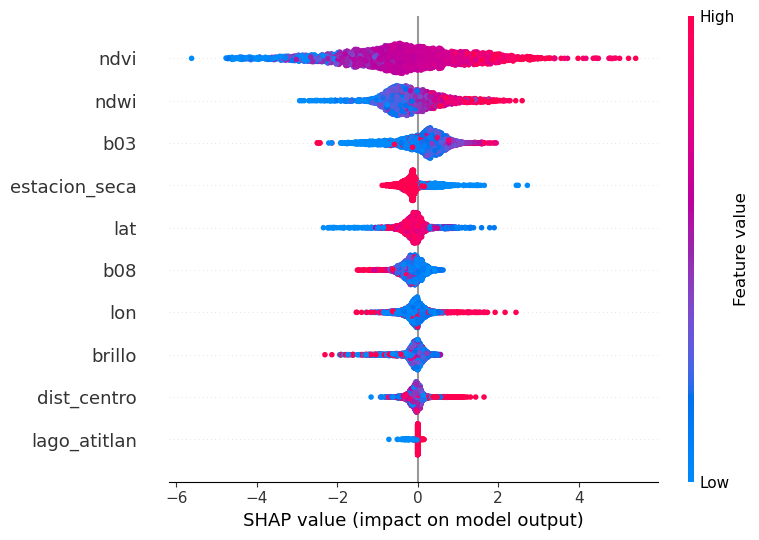

In [34]:
import shap

mejor_modelo_nombre = "XGBoost"
mejor_modelo = modelos_finales[mejor_modelo_nombre]
print("Modelo usado para interpretabilidad:", mejor_modelo_nombre)

X_sample = X_test.sample(n=3000, random_state=42)

if hasattr(mejor_modelo, "feature_importances_"):
    explainer = shap.TreeExplainer(mejor_modelo)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # clase 1 = alta presencia (SHAP viejo)
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]  # clase 1 = alta presencia (SHAP nuevo)
else:
    clf = mejor_modelo.named_steps["clf"]
    scaler = mejor_modelo.named_steps["scaler"]
    X_sample_scaled = pd.DataFrame(
        scaler.transform(X_sample), columns=X_sample.columns, index=X_sample.index
    )
    explainer = shap.LinearExplainer(clf, X_sample_scaled)
    shap_values = explainer.shap_values(X_sample_scaled)
    X_sample = X_sample_scaled  # para graficar en la misma escala que usa el modelo

shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("data/shap_summary_plot.png")
plt.show()

### 8.3–8.4 Interpretación ambiental

El SHAP Summary Plot muestra que **NDVI** es, por mucho, la variable más influyente:
valores altos empujan claramente la predicción hacia "alta presencia de cianobacteria",
y valores bajos hacia "baja presencia" — confirmando lo observado en la Parte I, donde
este índice (pensado originalmente para vegetación terrestre) resultó ser un buen
indicador indirecto de floraciones sobre el agua. El **NDWI** muestra una tendencia
similar pero más moderada.

La banda **b03** (verde) no tiene una relación simple: tanto valores muy altos como muy
bajos empujan hacia alta presencia, mientras que los valores intermedios empujan hacia
baja presencia. Esto sugiere que el modelo distingue dos escenarios distintos asociados
a floraciones —agua muy clara por un lado y agua muy cargada/turbia por el otro— en
lugar de una relación lineal de "a más reflectancia, más cianobacteria".

La **estación del año** también aporta información relevante: varias observaciones de
temporada de lluvias empujan hacia "alta presencia", mientras que la temporada seca
tiende a mantenerse neutral. Esto es coherente con el pico de cianobacteria detectado en
Amatitlán al inicio de las lluvias en la Parte I, probablemente por el arrastre de
nutrientes desde la cuenca.

Las variables geográficas también son informativas: las zonas más al **norte** de cada
lago y las más **alejadas del centro** (es decir, más cercanas a la orilla) tienden a
empujar hacia mayor probabilidad de alta presencia, mientras que el centro abierto del
lago empuja hacia baja presencia. Esto respalda lo ya visto de forma descriptiva en la
Parte I: las orillas, más expuestas a descargas de aguas residuales y escorrentía,
acumulan más cianobacteria que las zonas centrales.

Por último, la variable de **identidad del lago** (`lago_atitlan`) es la menos
influyente de todas. Esto es una señal positiva: indica que el modelo no está
simplemente "memorizando" en qué lago se encuentra para predecir, sino apoyándose
principalmente en el comportamiento espectral y espacial de cada punto. Es también
consistente con lo encontrado en el Ejercicio 7: como el mismo valor espectral puede
significar cosas distintas según el lago, un modelo que aprende estos patrones en un
lago no logra transferirlos bien al otro.

## Ejercicio 9. Generación de mapas predictivos

Usamos el mejor modelo (XGBoost, consistente con el Ejercicio 8) para calcular la probabilidad de alta presencia de cianobacteria en cada observación y la reconstruimos espacialmente para mapearla.

In [ ]:
df_ml["prob_alta"] = modelos_finales["XGBoost"].predict_proba(X)[:, 1]

print("Estadísticas de prob_alta por lago:")
display(df_ml.groupby("lago")["prob_alta"].describe().round(3))

Estadísticas de prob_alta por lago:


,count,mean,std,min,25%,50%,75%,max
lago,,,,,,,,
amatitlan,63309.0,0.289,0.397,0.000,0.004,0.033,0.675,1.000
atitlan,556754.0,0.399,0.292,0.001,0.122,0.360,0.656,0.994


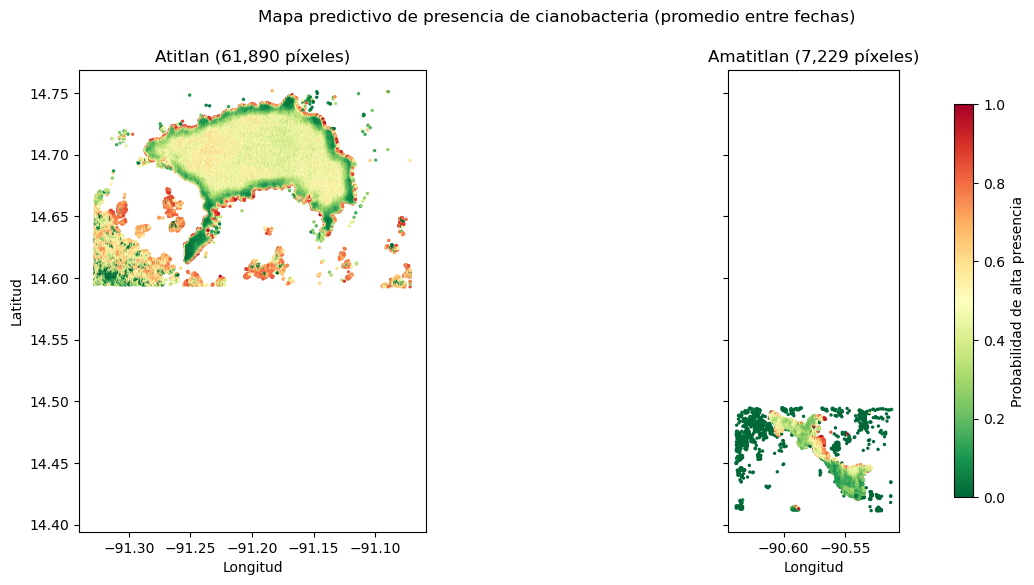

In [ ]:
prob_map = df_ml.groupby(["lago", "lon", "lat"])["prob_alta"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    sub = prob_map[prob_map["lago"] == lago]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["prob_alta"], cmap="RdYlGn_r",
                    vmin=0, vmax=1, s=2)
    ax.set_title(f"{lago.capitalize()} ({len(sub):,} píxeles)")
    ax.set_xlabel("Longitud")
    ax.set_aspect("equal")
axes[0].set_ylabel("Latitud")
cbar = fig.colorbar(sc, ax=axes.tolist(), shrink=0.85)
cbar.set_label("Probabilidad de alta presencia")
fig.suptitle("Mapa predictivo de presencia de cianobacteria (promedio entre fechas)")
plt.savefig("data/mapa_probabilidad_predictivo.png")
plt.show()

El mapa muestra el contraste esperado entre lagos: en **Amatitlán** gran parte del espejo de agua tiene probabilidades medias-altas (riesgo crónico y extendido), mientras que **Atitlán** se mantiene mayormente en riesgo bajo con focos localizados en sectores específicos. El patrón es coherente con lo visto en la Parte I y en los Ejercicios 1 y 8.

### 9.4 Escala por categorías

Se discretiza la probabilidad en cuatro clases con cortes fijos (0 / 0.25 / 0.50 / 0.75 / 1), para distinguir zonas de probabilidad muy baja, baja, alta y muy alta.

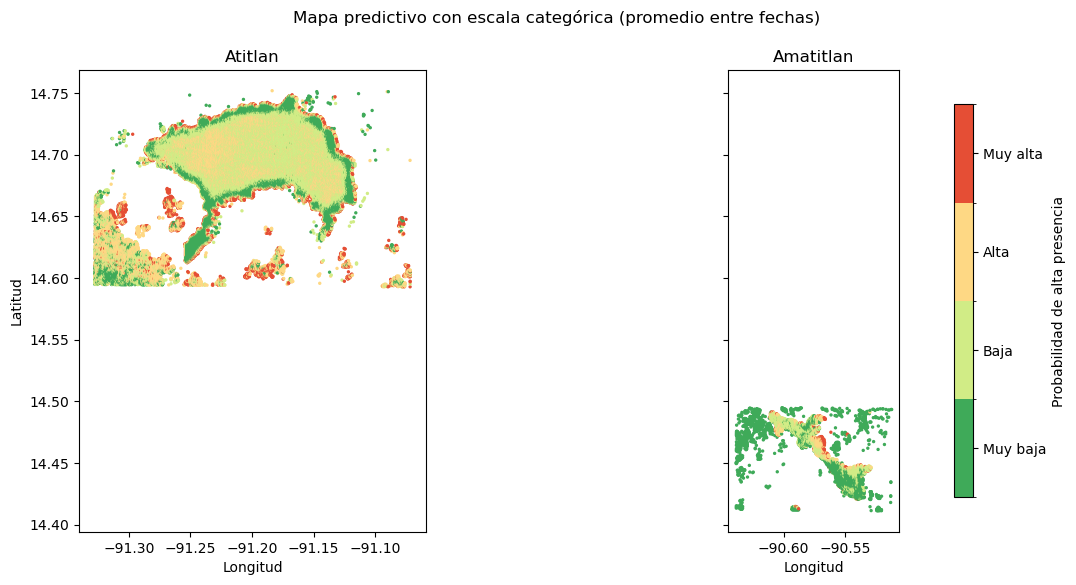

In [ ]:
from matplotlib.colors import BoundaryNorm, ListedColormap

cortes = [0, 0.25, 0.50, 0.75, 1.0]
cmap = ListedColormap(plt.get_cmap("RdYlGn_r")(np.linspace(0.15, 0.85, 4)))
norm = BoundaryNorm(cortes, cmap.N)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    sub = prob_map[prob_map["lago"] == lago]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["prob_alta"],
                    cmap=cmap, norm=norm, s=2)
    ax.set_title(lago.capitalize())
    ax.set_xlabel("Longitud")
    ax.set_aspect("equal")
axes[0].set_ylabel("Latitud")
cbar = fig.colorbar(sc, ax=axes.tolist(), shrink=0.85,
                     ticks=[0.125, 0.375, 0.625, 0.875])
cbar.ax.set_yticklabels(["Muy baja", "Baja", "Alta", "Muy alta"])
cbar.set_label("Probabilidad de alta presencia")
fig.suptitle("Mapa predictivo con escala categórica (promedio entre fechas)")
plt.savefig("data/mapa_probabilidad_categorias.png")
plt.show()

### 9.5 Comparación con los mapas de la Parte I

Comparamos el mapa predictivo contra el análogo observado de los mapas de cianobacteria de la Parte I (sección 8.2, zonas persistentes de acumulación): para cada píxel, la fracción de fechas en las que tuvo alta presencia.

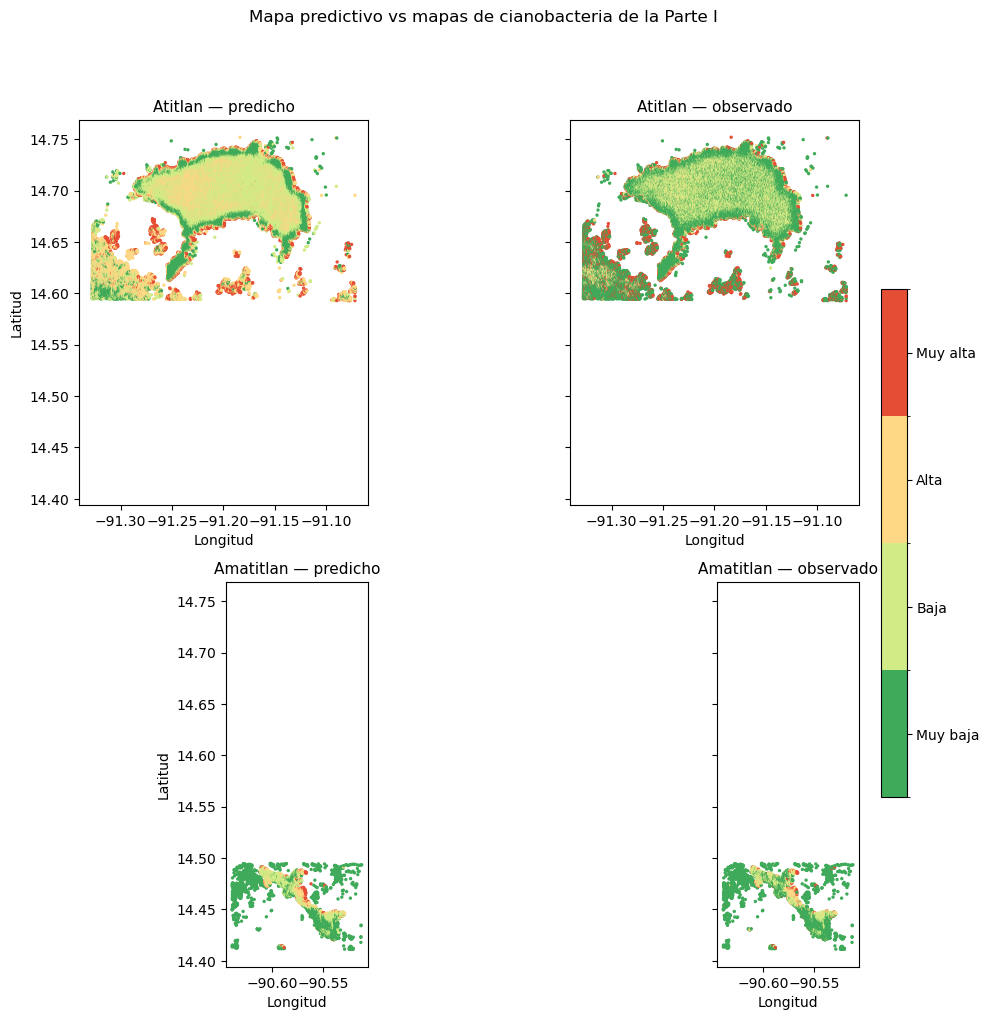

In [ ]:
obs_map = (
    df_ml.groupby(["lago", "lon", "lat"])["cianobacteria_binaria"]
    .mean().reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharey=True)
for i, lago in enumerate(["atitlan", "amatitlan"]):
    pred = prob_map[prob_map["lago"] == lago]
    obs = obs_map[obs_map["lago"] == lago]
    axes[i, 0].scatter(pred["lon"], pred["lat"], c=pred["prob_alta"],
                       cmap=cmap, norm=norm, s=2)
    axes[i, 1].scatter(obs["lon"], obs["lat"], c=obs["cianobacteria_binaria"],
                       cmap=cmap, norm=norm, s=2)
    axes[i, 0].set_ylabel("Latitud")
    axes[i, 0].set_title(f"{lago.capitalize()} — predicho", fontsize=11)
    axes[i, 1].set_title(f"{lago.capitalize()} — observado", fontsize=11)
    for ax in axes[i]:
        ax.set_xlabel("Longitud")
        ax.set_aspect("equal")
cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.6, pad=0.02,
                     ticks=[0.125, 0.375, 0.625, 0.875])
cbar.ax.set_yticklabels(["Muy baja", "Baja", "Alta", "Muy alta"])
fig.suptitle("Mapa predictivo vs mapas de cianobacteria de la Parte I")
plt.savefig("data/comparacion_prediccion_vs_observado.png")
plt.show()

El modelo reproduce bien el patrón espacial general: en **Amatitlán** ambas columnas marcan riesgo alto extendido sobre casi todo el espejo de agua, mientras que en **Atitlán** el riesgo queda concentrado en focos localizados dentro de una zona mayoritariamente baja. Las diferencias menores (focos muy puntuales que el modelo suaviza hacia categorías intermedias) son coherentes con su F1 ≈ 0.64: capta dónde está el riesgo, no píxel por píxel.

### 9.6 Zonas correctamente detectadas y errores de clasificación

Clasificamos cada observación comparando la clase predicha (`prob_alta >= 0.5`) contra la clase observada. Nota: al ser predicciones sobre todas las observaciones (incluye las de entrenamiento), el error mostrado subestima el error real del modelo.

Conteo de resultados por lago:


resultado,Falso negativo,Falso positivo,Verdadero negativo,Verdadero positivo
lago,,,,
amatitlan,685,2363,45121,15140
atitlan,25724,100072,317522,113436


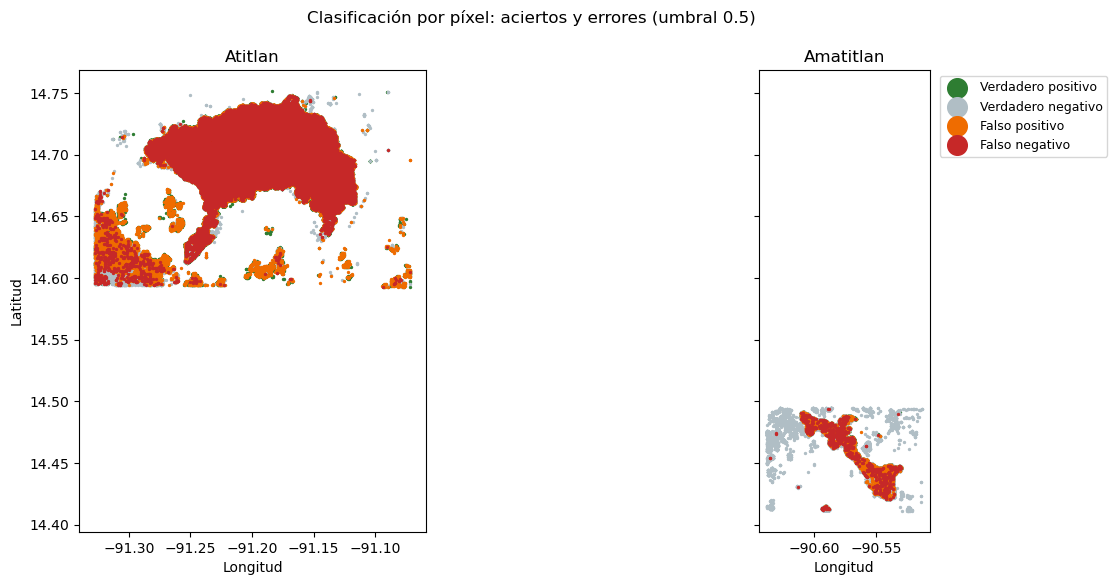

In [39]:
pred = (df_ml["prob_alta"] >= 0.5).astype(int)
obs = df_ml["cianobacteria_binaria"]

df_ml["resultado"] = np.select(
    [
        (pred == 1) & (obs == 1),
        (pred == 0) & (obs == 0),
        (pred == 1) & (obs == 0),
        (pred == 0) & (obs == 1),
    ],
    ["Verdadero positivo", "Verdadero negativo", "Falso positivo", "Falso negativo"],
)

print("Conteo de resultados por lago:")
display(df_ml.groupby(["lago", "resultado"]).size().unstack())

colores_res = {
    "Verdadero positivo": "#2e7d32",
    "Verdadero negativo": "#b0bec5",
    "Falso positivo": "#ef6c00",
    "Falso negativo": "#c62828",
}
orden = list(colores_res)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    sub = df_ml[df_ml["lago"] == lago]
    for cat in orden:
        s = sub[sub["resultado"] == cat]
        ax.scatter(s["lon"], s["lat"], c=colores_res[cat], s=2, label=cat)
    ax.set_title(lago.capitalize())
    ax.set_xlabel("Longitud")
    ax.set_aspect("equal")
axes[0].set_ylabel("Latitud")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1), markerscale=10, fontsize=9)
fig.suptitle("Clasificación por píxel: aciertos y errores (umbral 0.5)")
plt.savefig("data/mapa_errores_clasificacion.png", bbox_inches="tight")
plt.show()

### 9.7 Regiones con mayor dificultad predictiva

Agregamos la tasa de error por bloque espacial de 1 km (los definidos en el Ejercicio 6) para detectar zonas donde el modelo falla de forma sistemática.

Bloques con mayor tasa de error:


,lago,bloque_espacial,tasa_error
31,amatitlan,amatitlan_4_11,0.363636
75,amatitlan,amatitlan_7_8,0.333333
57,amatitlan,amatitlan_6_4,0.166667
56,amatitlan,amatitlan_6_3,0.140584
4,amatitlan,amatitlan_0_4,0.122449
162,atitlan,atitlan_11_27,1.000000
270,atitlan,atitlan_1_19,1.000000
323,atitlan,atitlan_4_25,1.000000
113,atitlan,atitlan_0_20,1.000000
310,atitlan,atitlan_3_4,0.875000


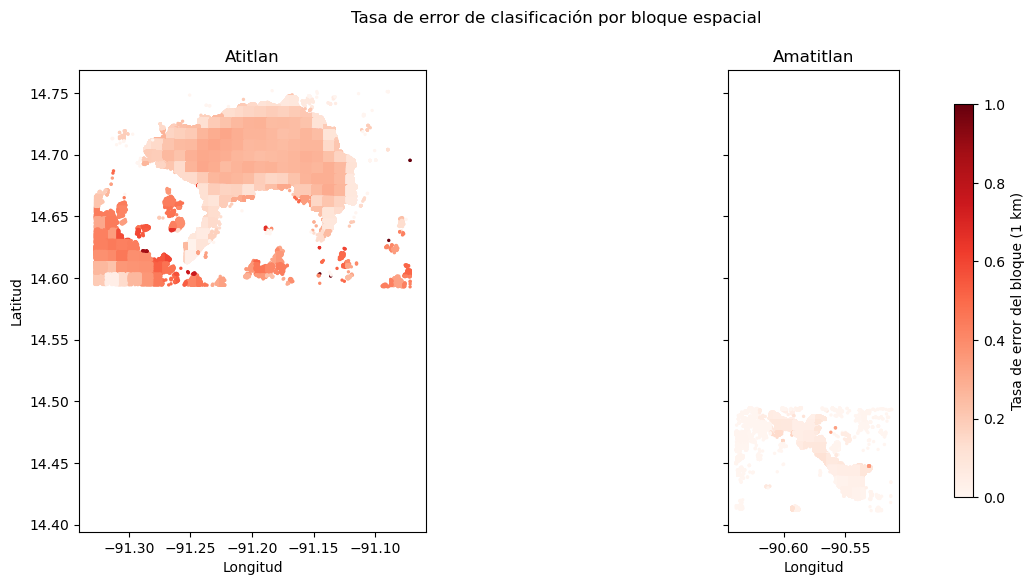

In [40]:
df_ml["error"] = df_ml["resultado"].isin(["Falso positivo", "Falso negativo"]).astype(int)

tasa_bloque = (
    df_ml.groupby(["lago", "bloque_espacial"])["error"]
    .mean().rename("tasa_error").reset_index()
)

peores = (
    tasa_bloque.sort_values("tasa_error", ascending=False)
    .groupby("lago").head(5)
    .sort_values(["lago", "tasa_error"], ascending=[True, False])
)
print("Bloques con mayor tasa de error:")
display(peores)

df_mapa = df_ml.merge(tasa_bloque, on=["lago", "bloque_espacial"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    sub = df_mapa[df_mapa["lago"] == lago]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["tasa_error"],
                    cmap="Reds", vmin=0, vmax=1, s=2)
    ax.set_title(lago.capitalize())
    ax.set_xlabel("Longitud")
    ax.set_aspect("equal")
axes[0].set_ylabel("Latitud")
cbar = fig.colorbar(sc, ax=axes.tolist(), shrink=0.85)
cbar.set_label("Tasa de error del bloque (1 km)")
fig.suptitle("Tasa de error de clasificación por bloque espacial")
plt.savefig("data/mapa_tasa_error_bloques.png")
plt.show()

Los errores tienden a concentrarse en **orillas y bordes de floración**, donde la señal es mixta (agua somera con sedimento o brillo residual), consistente con los píxeles atípicos brillantes vistos en el EDA. Los bloques más difíciles coinciden con zonas de **floración intermitente**: el índice varía fuertemente entre fechas y el modelo, que ve una imagen a la vez, no puede anticipar ese cambio. Ambos lagos muestran patrones parecidos, con más errores relativos en Amatitlán al tener mayor proporción de área en categorías intermedias y altas.